In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# import proplot as pplt
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import pyarrow.feather as feather
from scipy.stats import gaussian_kde


import pandas as pd
import geopandas as gpd
# attrs.set_index('gauge_id', inplace=True)

import io
import matplotlib.pyplot as plt
import matplotlib as mpl
import geopandas as gpd
# import proplot as pplt
import matplotlib as mpl
import geopandas as gpd
from matplotlib.ticker import FuncFormatter
import requests
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import xarray as xr

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import seaborn as sns

from pandas import read_feather

import os
import io
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import pyarrow.feather as feather
import matplotlib.pyplot as plt
from tqdm import tqdm
from __future__ import annotations
import os, warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# All Fluxes: Simulation_with_BASIN_CALIB_PARAMS

In [2]:

# ============================================================
# Global style
# ============================================================
plt.rcParams["font.family"] = "Georgia"
plt.rcParams["font.size"] = 12

# ============================================================
# Paths to results folders
# ============================================================
RESULT_DIR_BASE   = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_BASIN_CALIB_PARAMS\BASE_MODEL"
RESULT_DIR_BUDYKO = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_BASIN_CALIB_PARAMS\BUDYKO_MODEL"
RESULT_DIR_DA     = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_BASIN_CALIB_PARAMS\BUDYKO_DA"

METRIC_BASE_CSV   = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_BASIN_CALIB_PARAMS\BASE_MODEL\metrics_BASE.csv"
METRIC_BUDYKO_CSV = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_BASIN_CALIB_PARAMS\BUDYKO_MODEL\metrics_BUDYKO.csv"
METRIC_DA_CSV     = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_BASIN_CALIB_PARAMS\BUDYKO_DA\metrics_BUDYKO_DA.csv"

SFET_PATH         = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\data\processed\SFET.feather"

# ============================================================
# Helper: gauge_id from filename
# ============================================================
def get_gauge_id(fname: str) -> str:
    base = os.path.basename(fname)
    if base.endswith(".feather"):
        base = base[:-8]
    parts = base.split("_")
    return parts[-1].strip()

# ============================================================
# Helper: read "results_*.feather" from a folder
# ============================================================
def read_results_folder(result_dir: str, target_cols: list, desc_name: str) -> pd.DataFrame:
    files = [
        f for f in os.listdir(result_dir)
        if f.startswith("results_") and f.endswith(".feather")
    ]

    records = []

    for fname in tqdm(files, desc=f"Processing results in {desc_name}"):
        basin_id = get_gauge_id(fname)
        fpath = os.path.join(result_dir, fname)

        try:
            df = feather.read_feather(fpath)
            rec = {"gauge_id": basin_id}

            for c in target_cols:
                if c in df.columns:
                    rec[c] = pd.to_numeric(df[c], errors="coerce").mean(skipna=True)
                else:
                    rec[c] = np.nan

            records.append(rec)

        except Exception as e:
            print(f"⚠️ Skipping {basin_id} in {desc_name}: {e}")

    out = pd.DataFrame(records).drop_duplicates(subset=["gauge_id"])
    out = out.sort_values("gauge_id").reset_index(drop=True)
    return out

# ============================================================
# Helper: read "enkf_ensemble_BUDYKO_DA_*.feather"
# ============================================================
def read_ensemble_folder(result_dir: str, desc_name: str) -> pd.DataFrame:
    files = [
        f for f in os.listdir(result_dir)
        if f.startswith("enkf_ensemble_BUDYKO_DA_") and f.endswith(".feather")
    ]

    records = []

    for fname in tqdm(files, desc=f"Processing ensemble in {desc_name}"):
        basin_id = get_gauge_id(fname)
        fpath = os.path.join(result_dir, fname)

        try:
            df = feather.read_feather(fpath)

            rec = {
                "gauge_id": basin_id,
                "ET_ens_mean": pd.to_numeric(df["ET_ens_mean"], errors="coerce").mean(skipna=True) if "ET_ens_mean" in df.columns else np.nan,
                "Q_ens_mean":  pd.to_numeric(df["Q_ens_mean"],  errors="coerce").mean(skipna=True) if "Q_ens_mean"  in df.columns else np.nan,
                "S_ens_mean":  pd.to_numeric(df["S_ens_mean"],  errors="coerce").mean(skipna=True) if "S_ens_mean"  in df.columns else np.nan,
                "G_ens_mean":  pd.to_numeric(df["G_ens_mean"],  errors="coerce").mean(skipna=True) if "G_ens_mean"  in df.columns else np.nan,
            }

            records.append(rec)

        except Exception as e:
            print(f"⚠️ Skipping ensemble {fname}: {e}")

    out = pd.DataFrame(records).drop_duplicates(subset=["gauge_id"])
    out = out.sort_values("gauge_id").reset_index(drop=True)
    return out

# ============================================================
# Helper: safe merge without duplicate non-key columns
# ============================================================
def safe_merge(left: pd.DataFrame, right: pd.DataFrame, on: str = "gauge_id", how: str = "left") -> pd.DataFrame:
    overlap = [c for c in right.columns if c in left.columns and c != on]
    if overlap:
        right = right.drop(columns=overlap)
    return left.merge(right, on=on, how=how)

# ============================================================
# Target columns
# ============================================================
base_cols = [
    "P", "PET", "ET_ke", "S_base", "G_base", "Q_base"
]

budyko_cols = [
    "ET_B", "omega_true", "omega_MLR", "S_budyko", "G_budyko", "Q_obs", "Q_budyko"
]

da_results_cols = [
    "ET_ass", "Q_ass", "Q_ens"
]

# ============================================================
# Read simulation summaries
# ============================================================
base_df   = read_results_folder(RESULT_DIR_BASE, base_cols, "BASE_MODEL")
budyko_df = read_results_folder(RESULT_DIR_BUDYKO, budyko_cols, "BUDYKO_MODEL")
da_df_results  = read_results_folder(RESULT_DIR_DA, da_results_cols, "BUDYKO_DA (results)")
da_df_ensemble = read_ensemble_folder(RESULT_DIR_DA, "BUDYKO_DA (ensemble)")

da_df = safe_merge(da_df_results, da_df_ensemble, on="gauge_id", how="left")

all_simu_mean_505_basins = safe_merge(base_df, budyko_df, on="gauge_id", how="outer")
all_simu_mean_505_basins = safe_merge(all_simu_mean_505_basins, da_df, on="gauge_id", how="outer")

# standardize gauge_id
all_simu_mean_505_basins["gauge_id"] = all_simu_mean_505_basins["gauge_id"].astype(str).str.zfill(8)

# ============================================================
# Read metrics CSVs
# Keep ONLY the columns you actually need to avoid _x / _y
# ============================================================
KGE_Base = pd.read_csv(METRIC_BASE_CSV)
KGE_Budyko = pd.read_csv(METRIC_BUDYKO_CSV)
KGE_DA = pd.read_csv(METRIC_DA_CSV)

KGE_Base["gauge_id"] = KGE_Base["gauge_id"].astype(str).str.zfill(8)
KGE_Budyko["gauge_id"] = KGE_Budyko["gauge_id"].astype(str).str.zfill(8)
KGE_DA["gauge_id"] = KGE_DA["gauge_id"].astype(str).str.zfill(8)

KGE_Base = KGE_Base[["gauge_id", "KGE", "NSE"]].rename(
    columns={"KGE": "KGE_Base", "NSE": "NSE_Base"}
)

KGE_Budyko = KGE_Budyko[["gauge_id", "KGE", "NSE"]].rename(
    columns={"KGE": "KGE_Budyko", "NSE": "NSE_Budyko"}
)

KGE_DA = KGE_DA[["gauge_id", "KGE", "NSE"]].rename(
    columns={"KGE": "KGE_DA", "NSE": "NSE_DA"}
)

# ============================================================
# Read CAMELS attributes
# ============================================================
attr_url = "https://www.hydroshare.org/resource/658c359b8c83494aac0f58145b1b04e6/data/contents/camels_attributes_v2.0.feather?download=1"
r = requests.get(attr_url)
r.raise_for_status()

attrs = gpd.read_feather(io.BytesIO(r.content))
attrs = attrs.reset_index(drop=False)

# standardize gauge_id
attrs["gauge_id"] = attrs["gauge_id"].astype(str).str.zfill(8)

# keep only needed columns
attrs_keep = [
    "gauge_id",
    "q_mean",
    "runoff_ratio",
    "slope_fdc",
    "baseflow_index",
    "stream_elas",
    "p_mean",
    "pet_mean",
    "p_seasonality",
    "aridity",
    "frac_forest",
    "lai_max",
    "lai_diff",
    "gvf_max",
    "gvf_diff",
    "dom_land_cover_frac",
    "dom_land_cover",
    "elev_mean",
    "slope_mean",
    "geometry",
]
attrs = attrs[attrs_keep].copy()

# ============================================================
# Land cover mapping
# ============================================================
land_cover_mapping = {
    "Croplands": "CL/NVM",
    "cropland/natural vegetation mosaic": "CL/NVM",
    "Deciduous Broadleaf Forest": "DBF",
    "Evergreen Needleleaf Forest": "EF",
    "Evergreen Broadleaf Forest": "EF",
    "Mixed Forests": "MF",
    "Grasslands": "GL",
    "Savannas": "WS + SL",
    "Woody Savannas": "WS + SL",
    "Closed Shrublands": "WS + SL",
    "Open Shrublands": "WS + SL"
}

# ============================================================
# Merge everything cleanly
# ============================================================
attrs_all_simu_mean_505_basins = safe_merge(all_simu_mean_505_basins, attrs, on="gauge_id", how="left")
attrs_all_simu_mean_505_basins = safe_merge(attrs_all_simu_mean_505_basins, KGE_Base, on="gauge_id", how="left")
attrs_all_simu_mean_505_basins = safe_merge(attrs_all_simu_mean_505_basins, KGE_Budyko, on="gauge_id", how="left")
attrs_all_simu_mean_505_basins = safe_merge(attrs_all_simu_mean_505_basins, KGE_DA, on="gauge_id", how="left")

# ============================================================
# Derived columns
# ============================================================
attrs_all_simu_mean_505_basins["dom_land_cover_short"] = (
    attrs_all_simu_mean_505_basins["dom_land_cover"].map(land_cover_mapping)
)

attrs_all_simu_mean_505_basins["AI_base"] = (
    attrs_all_simu_mean_505_basins["PET"] / attrs_all_simu_mean_505_basins["P"]
)
attrs_all_simu_mean_505_basins["EI_base"] = (
    attrs_all_simu_mean_505_basins["ET_ke"] / attrs_all_simu_mean_505_basins["P"]
)

attrs_all_simu_mean_505_basins["AI_B"] = (
    attrs_all_simu_mean_505_basins["PET"] / attrs_all_simu_mean_505_basins["P"]
)
attrs_all_simu_mean_505_basins["EI_B"] = (
    attrs_all_simu_mean_505_basins["ET_B"] / attrs_all_simu_mean_505_basins["P"]
)

attrs_all_simu_mean_505_basins["AI_ass"] = (
    attrs_all_simu_mean_505_basins["PET"] / attrs_all_simu_mean_505_basins["P"]
)
attrs_all_simu_mean_505_basins["EI_ass"] = (
    attrs_all_simu_mean_505_basins["ET_ass"] / attrs_all_simu_mean_505_basins["P"]
)

# ============================================================
# Load SFET
# ============================================================
SFET = pd.read_feather(SFET_PATH)

SFET["time"] = pd.to_datetime(SFET["time"])
SFET = SFET.set_index("time").sort_index()
SFET.columns = SFET.columns.astype(str).str.strip()
SFET = SFET.loc[:, ~SFET.columns.duplicated()]

SFET_monthly = SFET.resample("MS").sum()
SFET_monthly.index.name = "time"

SFET_longterm = SFET_monthly.mean(axis=0, skipna=True).reset_index()
SFET_longterm.columns = ["gauge_id", "SFET"]
SFET_longterm["gauge_id"] = SFET_longterm["gauge_id"].astype(str).str.zfill(8)

attrs_all_simu_mean_505_basins = safe_merge(
    attrs_all_simu_mean_505_basins,
    SFET_longterm,
    on="gauge_id",
    how="left"
)

# optional final cleanup
# attrs_all_simu_mean_505_basins = attrs_all_simu_mean_505_basins.dropna(axis=0)

# ============================================================
# Final check
# ============================================================
# print(attrs_all_simu_mean_505_basins.columns)

dup_cols = attrs_all_simu_mean_505_basins.columns[
    attrs_all_simu_mean_505_basins.columns.duplicated()
]
print("Duplicated column names:", dup_cols.tolist())

attrs_all_simu_mean_505_basins_BASIN_CAL = attrs_all_simu_mean_505_basins
attrs_all_simu_mean_505_basins_BASIN_CAL

Processing ensemble in BUDYKO_DA (ensemble): 100%|██████████| 505/505 [01:04<00:00,  7.87it/s]


Duplicated column names: []


,gauge_id,P,PET,ET_ke,S_base,G_base,Q_base,ET_B,omega_true,omega_MLR,...,KGE_DA,NSE_DA,dom_land_cover_short,AI_base,EI_base,AI_B,EI_B,AI_ass,EI_ass,SFET
0,01013500,3.220468,1.965564,1.735084,0.032972,0.493977,2.498033,0.572399,1.231312,1.231312,...,0.045155,-0.551057,MF,0.610335,0.538768,0.610335,0.177738,0.610335,0.002175,38.572622
1,01022500,3.736526,2.097116,1.725228,1.286799,1.907910,2.118727,0.194807,1.063115,1.063115,...,0.577012,0.600278,MF,0.561248,0.461720,0.561248,0.052136,0.561248,0.046973,45.406795
2,01030500,3.443895,2.031945,1.706218,1.396647,0.519401,2.321640,1.073282,1.692289,1.705074,...,0.220041,-0.080559,MF,0.590014,0.495433,0.590014,0.311648,0.590014,0.010010,41.524708
3,01031500,3.596951,2.059864,1.686352,0.582811,0.578193,2.091093,0.673261,1.279575,1.281670,...,0.214490,0.088771,MF,0.572669,0.468828,0.572669,0.187175,0.572669,0.087314,39.285625
4,01047000,3.458845,2.081319,1.648486,138.726559,2.630745,2.698296,0.534395,1.216655,1.217180,...,0.601599,0.698553,MF,0.601738,0.476600,0.601738,0.154501,0.601738,0.146200,38.129020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
500,14306500,6.132429,2.944255,1.858909,8.483393,5.580589,4.601671,0.824798,1.431489,1.466773,...,0.752603,0.881923,EF,0.480112,0.303128,0.480112,0.134498,0.480112,0.002606,43.312292
501,14309500,4.477732,3.120722,1.870962,6.207661,1.644665,6.003380,0.962990,1.819453,1.857930,...,-0.198326,-1.347378,EF,0.696943,0.417837,0.696943,0.215062,0.696943,0.002980,48.131571
502,14316700,4.437725,2.270522,1.488833,4.657090,0.069909,2.986420,0.565250,1.347746,1.371279,...,0.831785,0.718343,EF,0.511641,0.335495,0.511641,0.127374,0.511641,0.181449,47.353741
503,14325000,5.664951,2.424180,1.935625,2.229999,2.899673,4.746949,0.550129,1.268688,1.277272,...,0.659336,0.845284,EF,0.427926,0.341684,0.427926,0.097111,0.427926,0.031975,46.947728


# Simulation_with_BASIN_CALIB_PARAMS: Hydrograph, FDC, scatter plots and Regime curves:


── 14139800  KGE_DA=0.876
  ✓  F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_BASIN_CALIB_PARAMS\Figures_Basin_Params\Figures_Basin_Params_14139800.png

── 14305500  KGE_DA=0.874
  ✓  F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_BASIN_CALIB_PARAMS\Figures_Basin_Params\Figures_Basin_Params_14305500.png

── 14236200  KGE_DA=0.865
  ✓  F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_BASIN_CALIB_PARAMS\Figures_Basin_Params\Figures_Basin_Params_14236200.png

── 14316700  KGE_DA=0.832
  ✓  F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_BASIN_CALIB_PARAMS\Figures_Basin_Params\Figures_Basin_Params_14316700.png

── 12040500  KGE_DA=0.825
  ✓  F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_BASIN_CALIB_PARAMS\Figures_Basin_Params\Figures_Basin_Params_12040500.png

── 03463300  KGE_DA=0.801
  ✓  F:\Github_repos\Bayesian_DA_Budyko_modeling

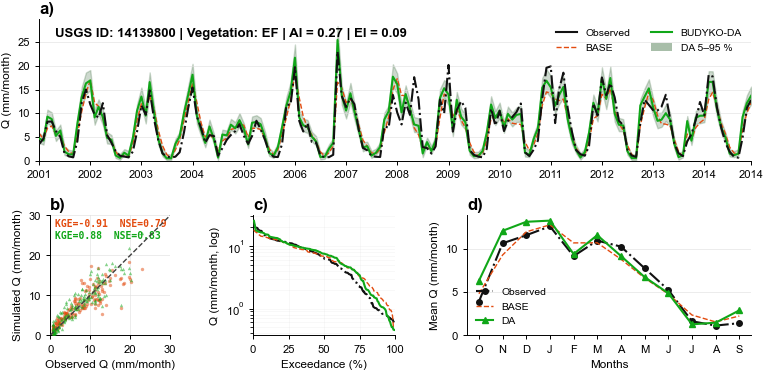

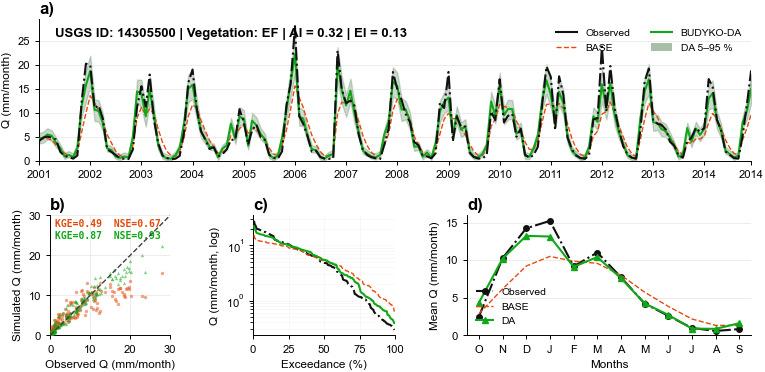

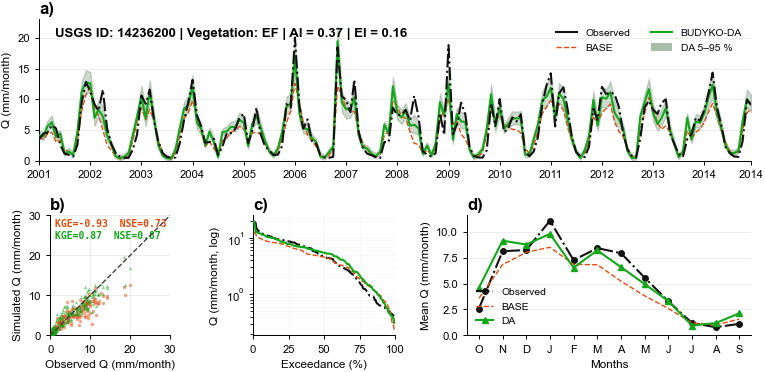

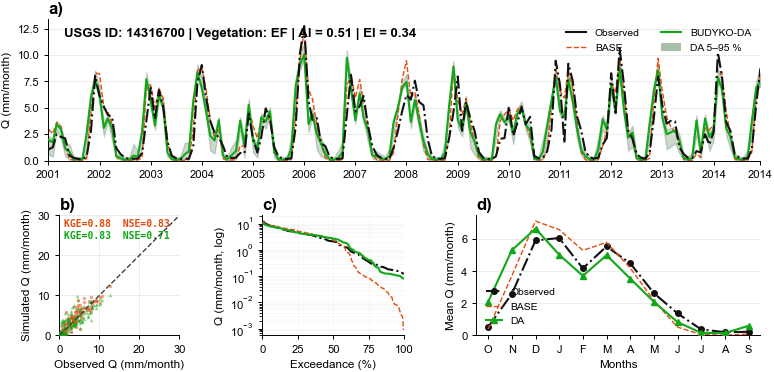

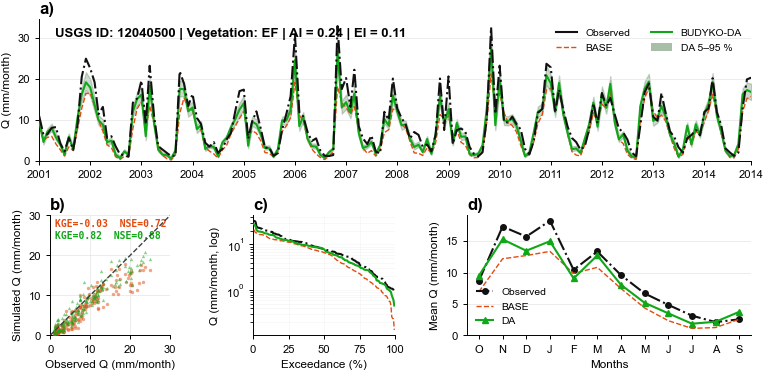

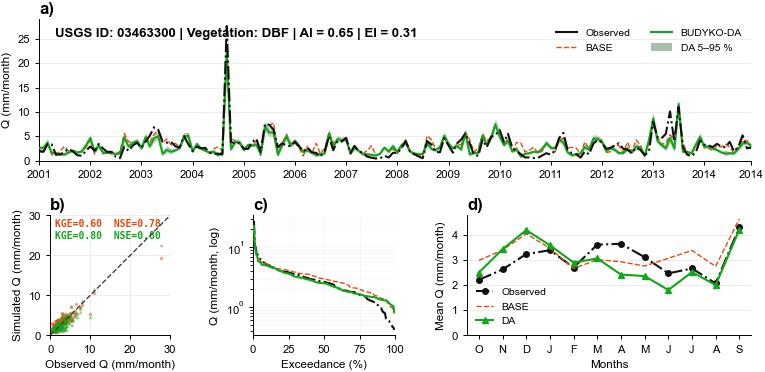

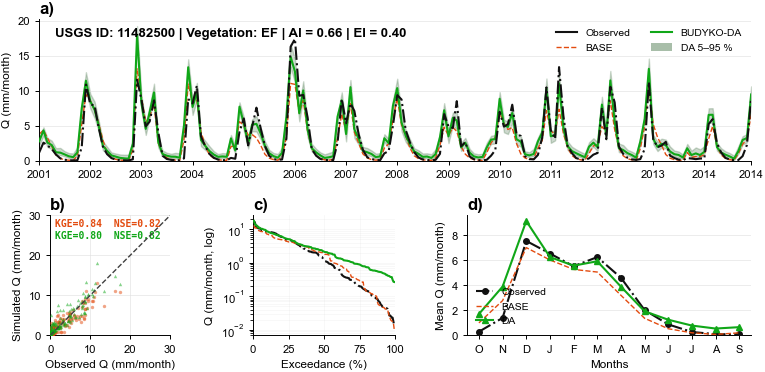

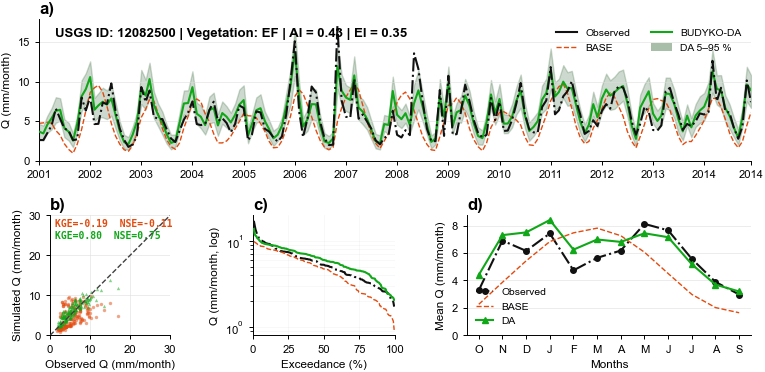

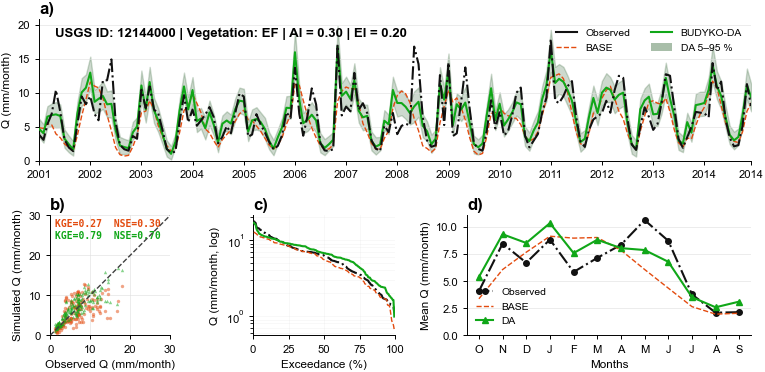

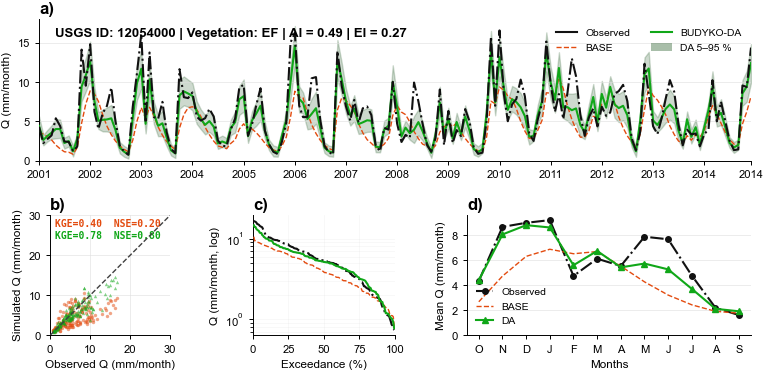

In [ ]:
warnings.filterwarnings("ignore")

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Arial", "DejaVu Sans"],
    "font.size": 8.5, "axes.titlesize": 9, "axes.labelsize": 8.5,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "legend.fontsize": 8, "legend.framealpha": 0.93, "legend.edgecolor": "0.65",
    "axes.linewidth": 0.7, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.major.width": 0.7, "xtick.major.size": 3,
    "ytick.major.width": 0.7, "ytick.major.size": 3,
    "grid.linewidth": 0.4, "grid.color": "0.87",
    "savefig.dpi": 300, "savefig.bbox": "tight", "pdf.fonttype": 42,
})

C  = dict(obs="#111111", base="#E34B0F", da="#10A718", ribbon="#08450B")
LW = dict(obs=1.5, base=1.0, da=1.5)
LS = dict(obs="-.", base="--", da="-")
MON = ["O","N","D","J","F","M","A","M","J","J","A","S"]


# ── Helpers ───────────────────────────────────────────────────────

def _load(path):
    df = pd.read_feather(path)
    for col in ("time", "Date", "date"):
        if col in df.columns:
            df[col] = pd.to_datetime(df[col])
            return df.set_index(col)
    return df

def _get(df, *cols):
    for c in cols:
        if c in df.columns:
            return df[c].values.astype(float)
    return np.full(len(df), np.nan)

def _align(v, si, ti):
    return pd.Series(v, index=si).reindex(ti).values.astype(float)

def _kge(o, s):
    m = np.isfinite(o) & np.isfinite(s); o, s = o[m], s[m]
    if len(o) < 3 or o.std() == 0: return np.nan
    r = np.corrcoef(o, s)[0, 1]
    return float(1 - np.sqrt((r-1)**2 + (s.std()/o.std()-1)**2 + (s.mean()/o.mean()-1)**2))

def _nse(o, s):
    m = np.isfinite(o) & np.isfinite(s); o, s = o[m], s[m]
    d = ((o - o.mean())**2).sum()
    return float(1 - ((o-s)**2).sum()/d) if d > 0 and len(o) > 2 else np.nan


# ── Panels ────────────────────────────────────────────────────────

def _ts(ax, t, obs, base, da, lo, hi):
    ax.fill_between(t, lo, hi, color=C["ribbon"], alpha=0.20, zorder=1)
    ax.plot(t, base, color=C["base"], lw=LW["base"], ls=LS["base"], zorder=2)
    ax.plot(t, da,   color=C["da"],   lw=LW["da"],   ls=LS["da"],   zorder=3)
    ax.plot(t, obs,  color=C["obs"],  lw=LW["obs"],  ls=LS["obs"],  zorder=4)
    ax.set_xlim(t[0], t[-1]); ax.set_ylim(bottom=0)
    ax.set_ylabel("Q (mm/month)")
    ax.set_title("a)", pad=4, loc="left", fontweight="bold", fontsize=12.0)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ticks = list(ax.get_xticks())
    t0n = mdates.date2num(pd.Timestamp(t[0]).to_pydatetime())
    t1n = mdates.date2num(pd.Timestamp(t[-1]).to_pydatetime())
    if ticks and abs(ticks[0]  - t0n) > 15: ticks = [t0n] + ticks
    if ticks and abs(ticks[-1] - t1n) > 15: ticks = ticks + [t1n]
    ax.set_xticks(ticks)
    plt.setp(ax.get_xticklabels(), rotation=0, ha="center")
    ax.grid(axis="y")


def _scatter(ax, obs, base, da, kge_b, kge_da, nse_b, nse_da):
    lim = max(np.nanmax([obs, base, da]) * 1.06, 1.0)
    for sim, color, marker in [(base, C["base"], "o"), (da, C["da"], "^")]:
        m = np.isfinite(obs) & np.isfinite(sim)
        ax.scatter(obs[m], sim[m], s=6, color=color, marker=marker,
                   alpha=0.50, linewidths=0, zorder=3)
    ax.plot([0, 100], [0, 100], color="0.25", lw=1.0, ls="--", zorder=5)
    ax.set_xlim(0, 30); ax.set_ylim(0, 30); ax.set_aspect("equal"); ax.grid(True)
    ax.set_xlabel("Observed Q (mm/month)"); ax.set_ylabel("Simulated Q (mm/month)")
    ax.set_title("b)", pad=4, loc="left", fontweight="bold", fontsize=12.0)
    for txt, col, y0 in [
        (f"KGE={kge_b:.2f}  NSE={nse_b:.2f}",  C["base"], 0.97),
        (f"KGE={kge_da:.2f}  NSE={nse_da:.2f}", C["da"],   0.87),
    ]:
        ax.text(0.04, y0, txt, transform=ax.transAxes, va="top", ha="left",
                fontsize=7, color=col, fontfamily="monospace", fontweight="bold")


def _fdc(ax, obs, base, da):
    def _f(x):
        v = np.sort(x[np.isfinite(x)])[::-1]
        return np.arange(1, len(v)+1)/(len(v)+1)*100, v
    for sim, color, ls, lw in [
        (obs,  C["obs"],  "-.", 1.5),
        (base, C["base"], "--", 1.0),
        (da,   C["da"],   "-",  1.5),
    ]:
        p, v = _f(sim)
        if len(v): ax.semilogy(p, v, color=color, lw=lw, ls=ls, zorder=3)
    ax.set_xlabel("Exceedance (%)"); ax.set_ylabel("Q (mm/month, log)")
    ax.set_xlim(0, 100); ax.grid(True, which="both", alpha=0.35)
    ax.set_title("c)", pad=4, loc="left", fontweight="bold", fontsize=12.0)


def _clim(ax, t, obs, base, da):
    mon  = np.array([d.month for d in t])
    xpos = np.array([(m - 10) % 12 for m in mon])
    for sim, color, ls, lw, marker, label in [
        (obs,  C["obs"],  "-.", 1.5, "o",  "Observed"),
        (base, C["base"], "--", 1.0, None, "BASE"),
        (da,   C["da"],   "-",  1.5, "^",  "DA"),
    ]:
        cl = np.array([np.nanmean(sim[xpos == x]) for x in range(12)])
        ax.plot(range(12), cl, color=color, lw=lw, ls=ls,
                marker=marker, ms=4, label=label, zorder=3)
    ax.set_xticks(range(12)); ax.set_xticklabels(MON)
    ax.set_xlim(-0.5, 11.5); ax.set_ylim(bottom=0)
    ax.set_xlabel("Months"); ax.set_ylabel("Mean Q (mm/month)")
    ax.grid(axis="y")
    ax.legend(loc="lower left", ncol=1, handlelength=1.6, fontsize=7.5, frameon=False)
    ax.set_title("d)", pad=4, loc="left", fontweight="bold", fontsize=12.0)


# ── Main ──────────────────────────────────────────────────────────

def plot_basin_Params(
    gauge_id: str,
    metrics_row: pd.Series,
    result_dir_base: str,
    # result_dir_budyko: str,
    result_dir_da: str,
    out_dir: str,
    start_year: int = 2001,
    end_year: int = 2014,
):
    gid = str(gauge_id).zfill(8)

    db  = _load(os.path.join(result_dir_base, f"results_BASE_{gid}.feather"))
    da  = _load(os.path.join(result_dir_da,   f"results_BUDYKO_DA_{gid}.feather"))
    ens = _load(os.path.join(result_dir_da,   f"enkf_ensemble_BUDYKO_DA_{gid}.feather"))

    t_all = ens.loc[f"{start_year}":f"{end_year}-12-31"].index
    obs   = _align(_get(db,  "Q_obs"),         db.index,  t_all)
    base  = _align(_get(db,  "Q_base","Q_ke"), db.index,  t_all)
    da_q  = _align(_get(da,  "Q_ass"),          da.index,  t_all)
    q_lo  = _align(_get(ens, "Q_ens_p05"),     ens.index, t_all)
    q_hi  = _align(_get(ens, "Q_ens_p95"),     ens.index, t_all)

    # KGE/NSE: use pre-computed from metrics_row; fall back to computing from data
    kge_b  = float(metrics_row.get("KGE_Base", _kge(obs, base)))
    kge_da = float(metrics_row.get("KGE_DA",   _kge(obs, da_q)))
    nse_b  = _nse(obs, base)
    nse_da = _nse(obs, da_q)

    fig = plt.figure(figsize=(8.0, 4.0))
    gs_outer = gridspec.GridSpec(2, 1, figure=fig,
                                 left=0.08, right=0.97, top=0.88, bottom=0.09,
                                 hspace=0.42, height_ratios=[1, 0.85])
    ax_ts = fig.add_subplot(gs_outer[0])
    gs_bot = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=gs_outer[1],
                                              wspace=0.38, width_ratios=[1, 1, 2])
    ax_sc  = fig.add_subplot(gs_bot[0])
    ax_fdc = fig.add_subplot(gs_bot[1])
    ax_cl  = fig.add_subplot(gs_bot[2])

    _ts(ax_ts, t_all, obs, base, da_q, q_lo, q_hi)
    _scatter(ax_sc, obs, base, da_q, kge_b, kge_da, nse_b, nse_da)
    _fdc(ax_fdc, obs, base, da_q)
    _clim(ax_cl, t_all, obs, base, da_q)

    ax_ts.legend(
        handles=[
            Line2D([0],[0], color=C["obs"],  lw=1.5, ls="-",  label="Observed"),
            Line2D([0],[0], color=C["base"], lw=1.0, ls="--", label="BASE"),
            Line2D([0],[0], color=C["da"],   lw=1.5, ls="-",  label="BUDYKO-DA"),
            Patch(fc=C["ribbon"], alpha=0.35,                 label="DA 5–95 %"),
        ],
        loc="upper right", ncol=2, fontsize=7.5, handlelength=2.0,
        framealpha=0.95, edgecolor="0.65", frameon=False,
    )

    ai  = metrics_row.get("AI_ass",  metrics_row.get("aridity",  np.nan))
    ei  = metrics_row.get("EI_base", metrics_row.get("EI_ass",   np.nan))
    veg = str(metrics_row.get("dom_land_cover_short", metrics_row.get("dom_land_cover", "—")))
    ai_s = f"{float(ai):.2f}" if pd.notna(ai) else "—"
    ei_s = f"{float(ei):.2f}" if pd.notna(ei) else "—"

    fig.suptitle(
        f"USGS ID: {gid} | Vegetation: {veg} | AI = {ai_s} | EI = {ei_s}",
        fontsize=9.5, fontweight="bold", x=0.1, y=0.86, ha="left",
    )

    os.makedirs(out_dir, exist_ok=True)
    path = os.path.join(out_dir, f"Figures_Basin_Params_{gid}.png")
    fig.savefig(path, dpi=300)
    print(f"  ✓  {path}")


def plot_top20_basin_Params(
    top20_df: pd.DataFrame,
    result_dir_base: str,
    result_dir_budyko: str,
    result_dir_da: str,
    out_dir: str,
    start_year: int = 2001,
    end_year: int = 2014,
):
    """One dashboard per row. Required cols: gauge_id, KGE_DA, KGE_Base."""
    for _, row in top20_df.iterrows():
        gid = str(row["gauge_id"]).zfill(8)
        print(f"\n── {gid}  KGE_DA={row['KGE_DA']:.3f}")
        plot_basin_Params(gid, row, result_dir_base, result_dir_budyko,
                          result_dir_da, out_dir, start_year, end_year)


# ── CONFIG ────────────────────────────────────────────────────────
if __name__ == "__main__":

    ROOT = r"F:\Github_repos\Bayesian_DA_Budyko_modeling"
    SIM  = os.path.join(ROOT, "Simulation_results", "Simulation_with_BASIN_CALIB_PARAMS")

    DIRS = dict(
        result_dir_base   = os.path.join(SIM, "BASE_MODEL"),
        result_dir_budyko = os.path.join(SIM, "BUDYKO_MODEL"),
        result_dir_da     = os.path.join(SIM, "BUDYKO_DA"),
        out_dir           = os.path.join(SIM, "Figures_Basin_Params"),
    )

    top20_KGE_DA = (
        attrs_all_simu_mean_505_basins_BASIN_CAL
        .dropna(subset=["KGE_DA"])
        .sort_values("KGE_DA", ascending=False)
        .head(10)
        .reset_index(drop=True)
    )
    plot_top20_basin_Params(top20_KGE_DA, **DIRS, start_year=2001, end_year=2014)

# Top-performing basins (6 basins):

Basins with KGE >= 0.50 in all scenarios: 4
  ✓  row 1  14316700
  ✓  row 2  03463300
  ✓  row 3  11482500
  ✓  row 4  11476600

  ✓  F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_BASIN_CALIB_PARAMS\figures\fig_basin_dashboard_6rows.png


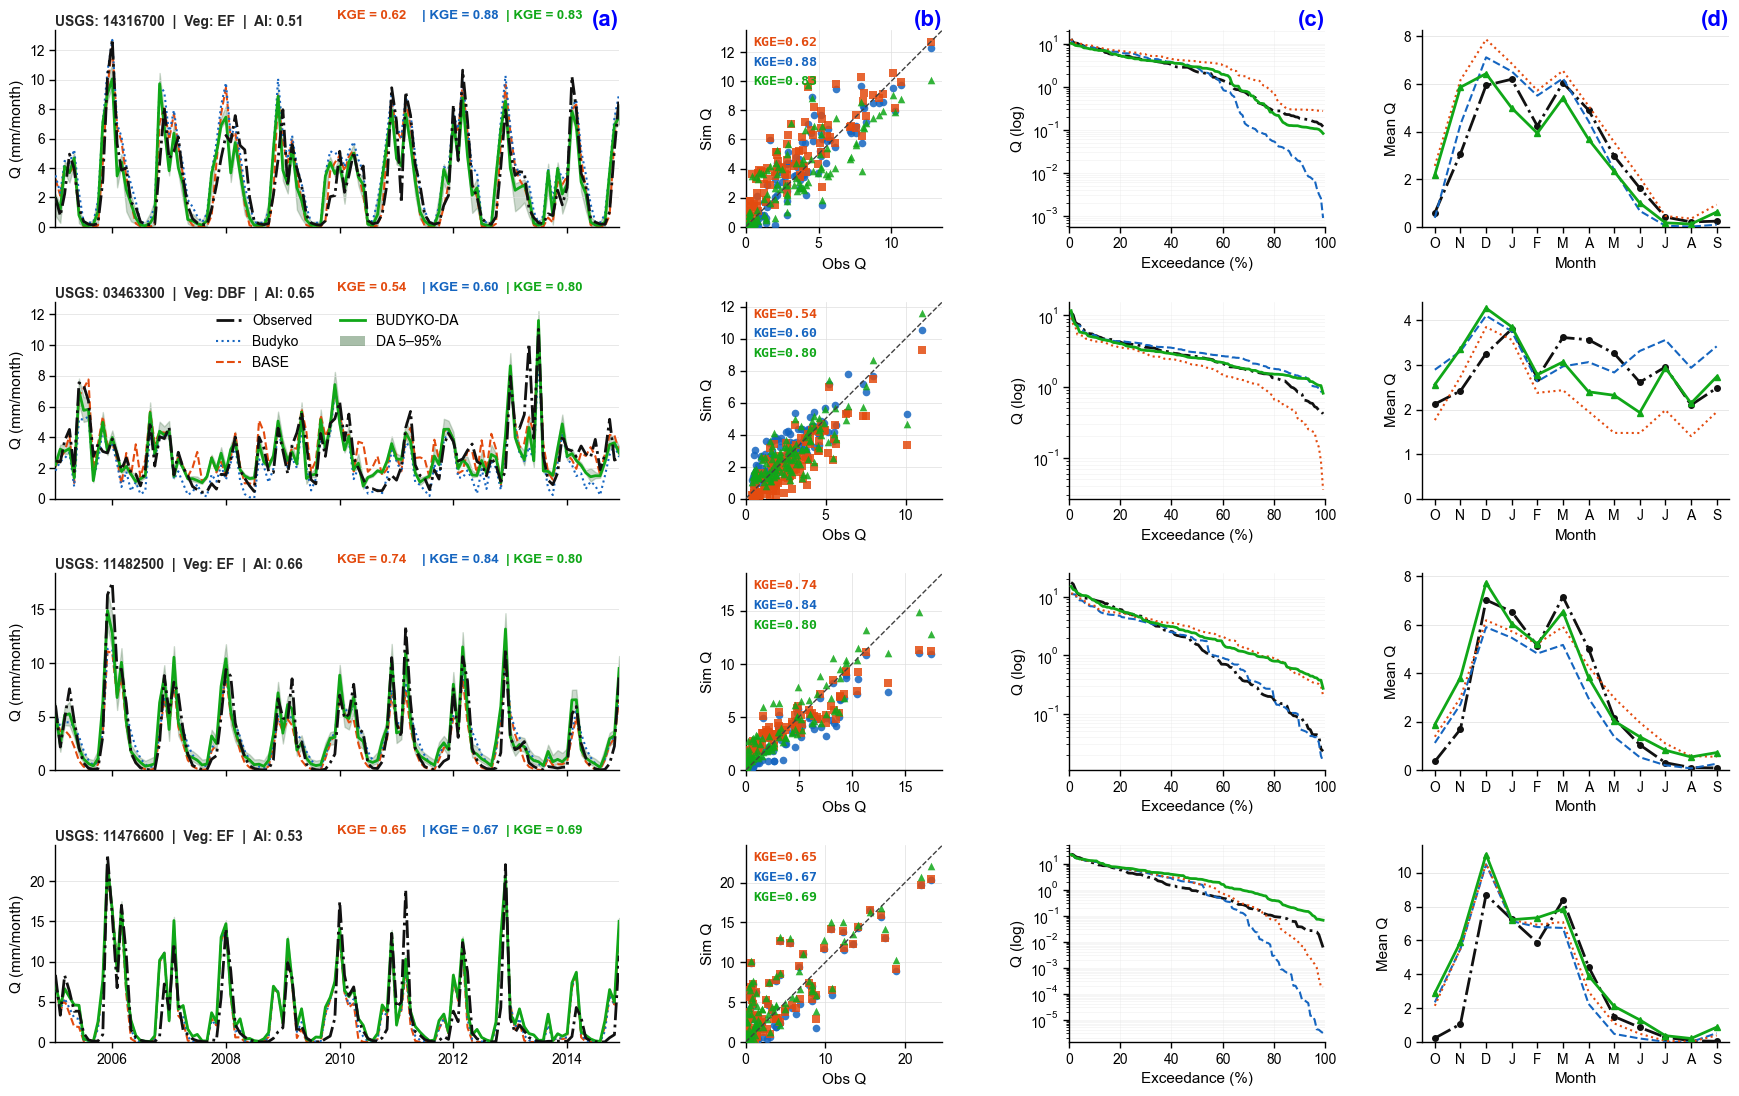

In [82]:
"""
plot_basin_dashboard_6rows.py
==============================
Six-basin dashboard — one row per basin, four panels per row.

Layout per row:  [ts (wide)] [scatter] [FDC] [seasonal]
                  col 0        col 1    col 2   col 3
                  width_ratio  1.8       1       1       1.2

All panel functions and styling are identical to plot_basin_Params.
Only the figure layout changes: 6 rows × 4 columns instead of 2 rows.

Call
----
    top6 = (attrs_df.dropna(subset=["KGE_DA"])
                    .sort_values("KGE_DA", ascending=False)
                    .head(6).reset_index(drop=True))
    plot_top6_dashboard(top6, result_dir_base, result_dir_da, out_dir)
"""

from __future__ import annotations
import os, warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

warnings.filterwarnings("ignore")

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Arial", "DejaVu Sans"],
    "font.size": 11, "axes.titlesize": 11, "axes.labelsize": 11,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "legend.fontsize": 10, "legend.framealpha": 0.93, "legend.edgecolor": "0.65",
    "axes.linewidth": 1.0, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.major.width": 1.0, "xtick.major.size": 4,
    "ytick.major.width": 1.0, "ytick.major.size": 4,
    "grid.linewidth": 0.5, "grid.color": "0.87",
    "savefig.dpi": 300, "savefig.bbox": "tight", "pdf.fonttype": 42,
})

C  = dict(obs="#111111", base="#E34B0F", bud="#1565C0", da="#10A718", ribbon="#08450B")
LW = dict(obs=2.0, base=1.5, bud=1.5, da=2.0)
LS = dict(obs="-.", base="--", bud=":", da="-")
MON = ["O","N","D","J","F","M","A","M","J","J","A","S"]


# ── Helpers (unchanged) ───────────────────────────────────────────

def _load(path):
    df = pd.read_feather(path)
    for col in ("time", "Date", "date"):
        if col in df.columns:
            df[col] = pd.to_datetime(df[col])
            return df.set_index(col)
    return df

def _get(df, *cols):
    for c in cols:
        if c in df.columns:
            return df[c].values.astype(float)
    return np.full(len(df), np.nan)

def _align(v, si, ti):
    return pd.Series(v, index=si).reindex(ti).values.astype(float)

def _kge(o, s):
    m = np.isfinite(o) & np.isfinite(s); o, s = o[m], s[m]
    if len(o) < 3 or o.std() == 0: return np.nan
    r = np.corrcoef(o, s)[0, 1]
    return float(1 - np.sqrt((r-1)**2 + (s.std()/o.std()-1)**2 + (s.mean()/o.mean()-1)**2))

def _nse(o, s):
    m = np.isfinite(o) & np.isfinite(s); o, s = o[m], s[m]
    d = ((o - o.mean())**2).sum()
    return float(1 - ((o-s)**2).sum()/d) if d > 0 and len(o) > 2 else np.nan


# ── Panel functions (unchanged) ───────────────────────────────────

def _ts(ax, t, obs, base, bud, da, lo, hi, first_row=False):
    ax.fill_between(t, lo, hi, color=C["ribbon"], alpha=0.20, zorder=1)
    ax.plot(t, base, color=C["base"], lw=LW["base"], ls=LS["base"], zorder=2)
    ax.plot(t, bud,  color=C["bud"],  lw=LW["bud"],  ls=LS["bud"],  zorder=3)
    ax.plot(t, da,   color=C["da"],   lw=LW["da"],   ls=LS["da"],   zorder=4)
    ax.plot(t, obs,  color=C["obs"],  lw=LW["obs"],  ls=LS["obs"],  zorder=5)
    ax.set_xlim(t[0], t[-1]); ax.set_ylim(bottom=0)
    ax.set_ylabel("Q (mm/month)")
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(axis="y")
    if not first_row:
        plt.setp(ax.get_xticklabels(), visible=False)


def _scatter(ax, obs, base, bud, da, kge_b, kge_bud, kge_da):
    lim = max(np.nanmax([obs, base, bud, da]) * 1.06, 1.0)
    for sim, color, marker in [
        (base, C["bud"], "o"),
        (bud,  C["base"],  "s"),
        (da,   C["da"],   "^"),
    ]:
        m = np.isfinite(obs) & np.isfinite(sim)
        ax.scatter(obs[m], sim[m], s=30, color=color, marker=marker,
                   alpha=0.85, linewidths=0, zorder=3)
    ax.plot([0, lim], [0, lim], color="0.25", lw=1.0, ls="--", zorder=5)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_aspect("equal"); ax.grid(True)
    ax.set_xlabel("Obs Q"); ax.set_ylabel("Sim Q")
    for txt, col, y0 in [
        (f"KGE={kge_bud:.2f}", C["base"],  0.97),
        (f"KGE={kge_b:.2f}",   C["bud"], 0.87),
        (f"KGE={kge_da:.2f}",  C["da"],   0.77),
    ]:
        ax.text(0.04, y0, txt, transform=ax.transAxes, va="top", ha="left",
                fontsize=9.5, color=col, fontfamily="monospace", fontweight="bold")


def _fdc(ax, obs, base, bud, da):
    def _f(x):
        v = np.sort(x[np.isfinite(x)])[::-1]
        return np.arange(1, len(v)+1)/(len(v)+1)*100, v
    for sim, color, ls, lw in [
        (obs,  C["obs"],  "-.", 2.0),
        (base, C["bud"], "--", 1.5),
        (bud,  C["base"],  ":",  1.5),
        (da,   C["da"],   "-",  2.0),
    ]:
        p, v = _f(sim)
        if len(v): ax.semilogy(p, v, color=color, lw=lw, ls=ls, zorder=3)
    ax.set_xlabel("Exceedance (%)"); ax.set_ylabel("Q (log)")
    ax.set_xlim(0, 100); ax.grid(True, which="both", alpha=0.35)


def _clim(ax, t, obs, base, bud, da):
    mon  = np.array([d.month for d in t])
    xpos = np.array([(m - 10) % 12 for m in mon])
    for sim, color, ls, lw, marker, label in [
        (obs,  C["obs"],  "-.", 2.0, "o",  "Observed"),
        (base, C["bud"], "--", 1.5, None, "BASE"),
        (bud,  C["base"],  ":",  1.5, None, "Budyko"),
        (da,   C["da"],   "-",  2.0, "^",  "BUDYKO-DA"),
    ]:
        cl = np.array([np.nanmean(sim[xpos == x]) for x in range(12)])
        ax.plot(range(12), cl, color=color, lw=lw, ls=ls,
                marker=marker, ms=4, label=label, zorder=3)
    ax.set_xticks(range(12)); ax.set_xticklabels(MON, fontsize=10)
    ax.set_xlim(-0.5, 11.5); ax.set_ylim(bottom=0)
    ax.set_xlabel("Month"); ax.set_ylabel("Mean Q")
    ax.grid(axis="y")
    # ax.legend(loc="upper right", fontsize=8, frameon=False, handlelength=1.5)



# ── Multi-basin figure ────────────────────────────────────────────

def plot_top6_dashboard(
    top6_df: pd.DataFrame,
    result_dir_base:   str,
    result_dir_budyko: str,
    result_dir_da:     str,
    out_dir: str,
    start_year: int = 2005,
    end_year:   int = 2014,
    fname: str = "fig_basin_dashboard_6rows",
):
    """
    One row per basin, four panels per row.
    Filters basins where KGE >= 0.5 in ALL three scenarios.
    top6_df must have columns: gauge_id, KGE_Base, KGE_Budyko, KGE_DA,
    and optionally: AI_ass/aridity, EI_base/EI_ass, dom_land_cover_short.
    """
    n_rows = len(top6_df)

    fig = plt.figure(figsize=(18.0, n_rows * 2.6 + 0.6))

    gs = gridspec.GridSpec(
        n_rows, 4, figure=fig,
        left=0.06, right=0.99,
        top=0.97,  bottom=0.05,
        hspace=0.38, wspace=0.28,
        width_ratios=[2.2, 1, 1, 1.2],
    )

    # Shared legend on the very first row time-series panel
    legend_drawn = False

    for row_i, (_, mrow) in enumerate(top6_df.iterrows()):
        gid = str(mrow["gauge_id"]).zfill(8)

        # Load data
        try:
            db  = _load(os.path.join(result_dir_base,   f"results_BASE_{gid}.feather"))
            dd  = _load(os.path.join(result_dir_budyko, f"results_BUDYKO_{gid}.feather"))
            da  = _load(os.path.join(result_dir_da,     f"results_BUDYKO_DA_{gid}.feather"))
            ens = _load(os.path.join(result_dir_da,     f"enkf_ensemble_BUDYKO_DA_{gid}.feather"))
        except FileNotFoundError as e:
            print(f"  ⚠  {gid}: {e}"); continue

        t_all = ens.loc[f"{start_year}":f"{end_year}-12-31"].index
        obs   = _align(_get(db,  "Q_obs"),              db.index,  t_all)
        base  = _align(_get(db,  "Q_base", "Q_ke"),     db.index,  t_all)
        bud_q = _align(_get(dd,  "Q_budyko", "Q_B"),    dd.index,  t_all)
        da_q  = _align(_get(da,  "Q_ass"),               da.index,  t_all)
        q_lo  = _align(_get(ens, "Q_ens_p05"),          ens.index, t_all)
        q_hi  = _align(_get(ens, "Q_ens_p95"),          ens.index, t_all)

        kge_b   = float(mrow.get("KGE_Base",   _kge(obs, base)))
        kge_bud = float(mrow.get("KGE_Budyko", _kge(obs, bud_q)))
        kge_da  = float(mrow.get("KGE_DA",     _kge(obs, da_q)))
        nse_b   = _nse(obs, base)
        nse_da  = _nse(obs, da_q)

        # Axes
        ax_ts  = fig.add_subplot(gs[row_i, 0])
        ax_sc  = fig.add_subplot(gs[row_i, 1])
        ax_fdc = fig.add_subplot(gs[row_i, 2])
        ax_cl  = fig.add_subplot(gs[row_i, 3])

        # Draw panels
        is_last = (row_i == n_rows - 1)
        _ts(ax_ts, t_all, obs, base, bud_q, da_q, q_lo, q_hi, first_row=is_last)
        _scatter(ax_sc, obs, base, bud_q, da_q, kge_b, kge_bud, kge_da)
        _fdc(ax_fdc, obs, base, bud_q, da_q)
        _clim(ax_cl, t_all, obs, base, bud_q, da_q)

        # Row title: basin ID, vegetation, AI — then colour-coded KGE per scenario
        ai  = mrow.get("AI_ass",  mrow.get("aridity",  np.nan))
        veg = str(mrow.get("dom_land_cover_short",
                            mrow.get("dom_land_cover", "—")))
        ai_s = f"{float(ai):.2f}" if pd.notna(ai) else "—"

        # Plain text prefix
        ax_ts.set_title(
            f"USGS: {gid}  |  Veg: {veg}  |  AI: {ai_s}",
            loc="left", fontsize=10, fontweight="bold", pad=3, color="0.15",
        )
        # Colour-coded KGE values — no subscripts, color identifies scenario
        for x_off, kge_val, col, txt in [
            (0.50, kge_bud, C["base"], f"KGE = {kge_bud:.2f}"),
            (0.65, kge_b,   C["bud"],  f"| KGE = {kge_b:.2f}"),
            (0.80, kge_da,  C["da"],   f"| KGE = {kge_da:.2f}"),
        ]:
            ax_ts.text(
                x_off, 1.04, txt,
                transform=ax_ts.transAxes,
                fontsize=9.5, fontweight="bold",
                color=col, va="bottom", ha="left", clip_on=False
            )
        # Panel labels (a–d) on first row only
        if row_i == 0:
            for ax, lbl in zip([ax_ts, ax_sc, ax_fdc, ax_cl],
                                ["(a)", "(b)", "(c)", "(d)"]):
                ax.set_title(lbl, loc="right", fontsize=16,
                             fontweight="bold", pad=3, color="blue")

        # Shared legend on first row time-series panel
        if row_i == 1 and not legend_drawn:
            ax_ts.legend(
                handles=[
                    Line2D([0],[0], color=C["obs"],  lw=2.0, ls="-.",
                           label="Observed"),
                    Line2D([0],[0], color=C["bud"],  lw=1.5, ls=":",
                           label="Budyko"),
                    Line2D([0],[0], color=C["base"], lw=1.5, ls="--",
                           label="BASE"),
                    Line2D([0],[0], color=C["da"],   lw=2.0, ls="-",
                           label="BUDYKO-DA"),
                    Patch(fc=C["ribbon"], alpha=0.35, label="DA 5–95%"),
                ],
                loc="upper center", ncol=2, fontsize=10,
                handlelength=1.8, frameon=False, edgecolor="0.65",
            )
            legend_drawn = True

        print(f"  ✓  row {row_i+1}  {gid}")

    os.makedirs(out_dir, exist_ok=True)
    path = os.path.join(out_dir, f"{fname}.png")
    fig.savefig(path, dpi=300)
    print(f"\n  ✓  {path}")
    plt.show()
    return fig


# ── Entry point ───────────────────────────────────────────────────

if __name__ == "__main__":

    ROOT = r"F:\Github_repos\Bayesian_DA_Budyko_modeling"
    SIM  = os.path.join(ROOT, "Simulation_results",
                        "Simulation_with_BASIN_CALIB_PARAMS")

    df = attrs_all_simu_mean_505_basins_BASIN_CAL
    top6 = (
        df.dropna(subset=["KGE_Base","KGE_Budyko","KGE_DA"])
        .loc[
            (df["KGE_Base"]   >= 0.50) &
            (df["KGE_Budyko"] >= 0.50) &
            (df["KGE_DA"]     >= 0.50)
        ]
        .sort_values("KGE_DA", ascending=False)
        .head(6)
        .reset_index(drop=True)
    )
    print(f"Basins with KGE >= 0.50 in all scenarios: {len(top6)}")

    plot_top6_dashboard(
        top6_df           = top6,
        result_dir_base   = os.path.join(SIM, "BASE_MODEL"),
        result_dir_budyko = os.path.join(SIM, "BUDYKO_MODEL"),
        result_dir_da     = os.path.join(SIM, "BUDYKO_DA"),
        out_dir           = os.path.join(SIM, "figures"),
    )

# All Fluxes: Simulation_with_GLOBAL_CAL_PARAMS

In [203]:

# ============================================================
# Global style
# ============================================================
plt.rcParams["font.family"] = "Georgia"
plt.rcParams["font.size"] = 12

# ============================================================
# Paths to results folders
# ============================================================
RESULT_DIR_BASE   = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_GLOBAL_CAL_PARAMS\BASE_MODEL\TEST"
RESULT_DIR_BUDYKO = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_GLOBAL_CAL_PARAMS\BUDYKO_MODEL\TEST"
RESULT_DIR_DA     = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_GLOBAL_CAL_PARAMS\BUDYKO_DA\TEST"

METRIC_BASE_CSV   = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_GLOBAL_CAL_PARAMS\BASE_MODEL\TEST\metrics_BASE_test.csv"
METRIC_BUDYKO_CSV = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_GLOBAL_CAL_PARAMS\BUDYKO_MODEL\TEST\metrics_BUDYKO_test.csv"
METRIC_DA_CSV     = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_GLOBAL_CAL_PARAMS\BUDYKO_DA\TEST\metrics_BUDYKO_DA_test.csv"

SFET_PATH         = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\data\processed\SFET.feather"

# ============================================================
# Helper: gauge_id from filename
# ============================================================
def get_gauge_id(fname: str) -> str:
    base = os.path.basename(fname)
    if base.endswith(".feather"):
        base = base[:-8]
    parts = base.split("_")
    return parts[-1].strip()

# ============================================================
# Helper: read "results_*.feather" from a folder
# ============================================================
def read_results_folder(result_dir: str, target_cols: list, desc_name: str) -> pd.DataFrame:
    files = [
        f for f in os.listdir(result_dir)
        if f.startswith("results_") and f.endswith(".feather")
    ]

    records = []

    for fname in tqdm(files, desc=f"Processing results in {desc_name}"):
        basin_id = get_gauge_id(fname)
        fpath = os.path.join(result_dir, fname)

        try:
            df = feather.read_feather(fpath)
            rec = {"gauge_id": basin_id}

            for c in target_cols:
                if c in df.columns:
                    rec[c] = pd.to_numeric(df[c], errors="coerce").mean(skipna=True)
                else:
                    rec[c] = np.nan

            records.append(rec)

        except Exception as e:
            print(f"⚠️ Skipping {basin_id} in {desc_name}: {e}")

    out = pd.DataFrame(records).drop_duplicates(subset=["gauge_id"])
    out = out.sort_values("gauge_id").reset_index(drop=True)
    return out

# ============================================================
# Helper: read "enkf_ensemble_BUDYKO_DA_*.feather"
# ============================================================
def read_ensemble_folder(result_dir: str, desc_name: str) -> pd.DataFrame:
    files = [
        f for f in os.listdir(result_dir)
        if f.startswith("enkf_ensemble_BUDYKO_DA_") and f.endswith(".feather")
    ]

    records = []

    for fname in tqdm(files, desc=f"Processing ensemble in {desc_name}"):
        basin_id = get_gauge_id(fname)
        fpath = os.path.join(result_dir, fname)

        try:
            df = feather.read_feather(fpath)

            rec = {
                "gauge_id": basin_id,
                "ET_ens_mean": pd.to_numeric(df["ET_ens_mean"], errors="coerce").mean(skipna=True) if "ET_ens_mean" in df.columns else np.nan,
                "Q_ens_mean":  pd.to_numeric(df["Q_ens_mean"],  errors="coerce").mean(skipna=True) if "Q_ens_mean"  in df.columns else np.nan,
                "S_ens_mean":  pd.to_numeric(df["S_ens_mean"],  errors="coerce").mean(skipna=True) if "S_ens_mean"  in df.columns else np.nan,
                "G_ens_mean":  pd.to_numeric(df["G_ens_mean"],  errors="coerce").mean(skipna=True) if "G_ens_mean"  in df.columns else np.nan,
            }

            records.append(rec)

        except Exception as e:
            print(f"⚠️ Skipping ensemble {fname}: {e}")

    out = pd.DataFrame(records).drop_duplicates(subset=["gauge_id"])
    out = out.sort_values("gauge_id").reset_index(drop=True)
    return out

# ============================================================
# Helper: safe merge without duplicate non-key columns
# ============================================================
def safe_merge(left: pd.DataFrame, right: pd.DataFrame, on: str = "gauge_id", how: str = "left") -> pd.DataFrame:
    overlap = [c for c in right.columns if c in left.columns and c != on]
    if overlap:
        right = right.drop(columns=overlap)
    return left.merge(right, on=on, how=how)

# ============================================================
# Target columns
# ============================================================
base_cols = [
    "P", "PET", "ET_ke", "S_base", "G_base", "Q_base"
]

budyko_cols = [
    "ET_B",  "omega_MLR", "S_budyko", "G_budyko", "Q_obs", "Q_budyko"  #"omega_true",
]

da_results_cols = [
    "ET_ass", "Q_ass", "Q_ens"
]

# ============================================================
# Read simulation summaries
# ============================================================
base_df   = read_results_folder(RESULT_DIR_BASE, base_cols, "BASE_MODEL")
budyko_df = read_results_folder(RESULT_DIR_BUDYKO, budyko_cols, "BUDYKO_MODEL")
da_df_results  = read_results_folder(RESULT_DIR_DA, da_results_cols, "BUDYKO_DA (results)")
da_df_ensemble = read_ensemble_folder(RESULT_DIR_DA, "BUDYKO_DA (ensemble)")

da_df = safe_merge(da_df_results, da_df_ensemble, on="gauge_id", how="left")

all_simu_mean_505_basins = safe_merge(base_df, budyko_df, on="gauge_id", how="outer")
all_simu_mean_505_basins = safe_merge(all_simu_mean_505_basins, da_df, on="gauge_id", how="outer")

# standardize gauge_id
all_simu_mean_505_basins["gauge_id"] = all_simu_mean_505_basins["gauge_id"].astype(str).str.zfill(8)

# ============================================================
# Read metrics CSVs
# Keep ONLY the columns you actually need to avoid _x / _y
# ============================================================
KGE_Base = pd.read_csv(METRIC_BASE_CSV)
KGE_Budyko = pd.read_csv(METRIC_BUDYKO_CSV)
KGE_DA = pd.read_csv(METRIC_DA_CSV)

KGE_Base["gauge_id"] = KGE_Base["gauge_id"].astype(str).str.zfill(8)
KGE_Budyko["gauge_id"] = KGE_Budyko["gauge_id"].astype(str).str.zfill(8)
KGE_DA["gauge_id"] = KGE_DA["gauge_id"].astype(str).str.zfill(8)

KGE_Base = KGE_Base[["gauge_id", "KGE", "NSE"]].rename(
    columns={"KGE": "KGE_Base", "NSE": "NSE_Base"}
)

KGE_Budyko = KGE_Budyko[["gauge_id", "KGE", "NSE"]].rename(
    columns={"KGE": "KGE_Budyko", "NSE": "NSE_Budyko"}
)

KGE_DA = KGE_DA[["gauge_id", "KGE", "NSE"]].rename(
    columns={"KGE": "KGE_DA", "NSE": "NSE_DA"}
)

# ============================================================
# Read CAMELS attributes
# ============================================================
attr_url = "https://www.hydroshare.org/resource/658c359b8c83494aac0f58145b1b04e6/data/contents/camels_attributes_v2.0.feather?download=1"
r = requests.get(attr_url)
r.raise_for_status()

attrs = gpd.read_feather(io.BytesIO(r.content))
attrs = attrs.reset_index(drop=False)

# standardize gauge_id
attrs["gauge_id"] = attrs["gauge_id"].astype(str).str.zfill(8)

# keep only needed columns
attrs_keep = [
    "gauge_id",
    "q_mean",
    "runoff_ratio",
    "slope_fdc",
    "baseflow_index",
    "stream_elas",
    "p_mean",
    "pet_mean",
    "p_seasonality",
    "aridity",
    "frac_forest",
    "lai_max",
    "lai_diff",
    "gvf_max",
    "gvf_diff",
    "dom_land_cover_frac",
    "dom_land_cover",
    "elev_mean",
    "slope_mean",
    "geometry",
]
attrs = attrs[attrs_keep].copy()

# ============================================================
# Land cover mapping
# ============================================================
land_cover_mapping = {
    "Croplands": "CL/NVM",
    "cropland/natural vegetation mosaic": "CL/NVM",
    "Deciduous Broadleaf Forest": "DBF",
    "Evergreen Needleleaf Forest": "EF",
    "Evergreen Broadleaf Forest": "EF",
    "Mixed Forests": "MF",
    "Grasslands": "GL",
    "Savannas": "WS + SL",
    "Woody Savannas": "WS + SL",
    "Closed Shrublands": "WS + SL",
    "Open Shrublands": "WS + SL"
}

# ============================================================
# Merge everything cleanly
# ============================================================
attrs_all_simu_mean_505_basins = safe_merge(all_simu_mean_505_basins, attrs, on="gauge_id", how="left")
attrs_all_simu_mean_505_basins = safe_merge(attrs_all_simu_mean_505_basins, KGE_Base, on="gauge_id", how="left")
attrs_all_simu_mean_505_basins = safe_merge(attrs_all_simu_mean_505_basins, KGE_Budyko, on="gauge_id", how="left")
attrs_all_simu_mean_505_basins = safe_merge(attrs_all_simu_mean_505_basins, KGE_DA, on="gauge_id", how="left")

# ============================================================
# Derived columns
# ============================================================
attrs_all_simu_mean_505_basins["dom_land_cover_short"] = (
    attrs_all_simu_mean_505_basins["dom_land_cover"].map(land_cover_mapping)
)

attrs_all_simu_mean_505_basins["AI_base"] = (
    attrs_all_simu_mean_505_basins["PET"] / attrs_all_simu_mean_505_basins["P"]
)
attrs_all_simu_mean_505_basins["EI_base"] = (
    attrs_all_simu_mean_505_basins["ET_ke"] / attrs_all_simu_mean_505_basins["P"]
)

attrs_all_simu_mean_505_basins["AI_B"] = (
    attrs_all_simu_mean_505_basins["PET"] / attrs_all_simu_mean_505_basins["P"]
)
attrs_all_simu_mean_505_basins["EI_B"] = (
    attrs_all_simu_mean_505_basins["ET_B"] / attrs_all_simu_mean_505_basins["P"]
)

attrs_all_simu_mean_505_basins["AI_ass"] = (
    attrs_all_simu_mean_505_basins["PET"] / attrs_all_simu_mean_505_basins["P"]
)
attrs_all_simu_mean_505_basins["EI_ass"] = (
    attrs_all_simu_mean_505_basins["ET_ass"] / attrs_all_simu_mean_505_basins["P"]
)

# # ============================================================
# # Load SFET
# # ============================================================
# SFET = pd.read_feather(SFET_PATH)

# SFET["time"] = pd.to_datetime(SFET["time"])
# SFET = SFET.set_index("time").sort_index()
# SFET.columns = SFET.columns.astype(str).str.strip()
# SFET = SFET.loc[:, ~SFET.columns.duplicated()]

# SFET_monthly = SFET.resample("MS").sum()
# SFET_monthly.index.name = "time"

# SFET_longterm = SFET_monthly.mean(axis=0, skipna=True).reset_index()
# SFET_longterm.columns = ["gauge_id", "SFET"]
# SFET_longterm["gauge_id"] = SFET_longterm["gauge_id"].astype(str).str.zfill(8)

# attrs_all_simu_mean_505_basins = safe_merge(
#     attrs_all_simu_mean_505_basins,
#     SFET_longterm,
#     on="gauge_id",
#     how="left"
# )

# # optional final cleanup
# attrs_all_simu_mean_505_basins = attrs_all_simu_mean_505_basins.dropna(axis=0)

# # ============================================================
# # Final check
# # ============================================================
# # print(attrs_all_simu_mean_505_basins.columns)

# dup_cols = attrs_all_simu_mean_505_basins.columns[
#     attrs_all_simu_mean_505_basins.columns.duplicated()
# ]
# print("Duplicated column names:", dup_cols.tolist())

attrs_all_simu_mean_505_basins_GLOBAL_CAL = attrs_all_simu_mean_505_basins
common_idx = attrs_all_simu_mean_505_basins_GLOBAL_CAL.index.intersection(
    attrs_all_simu_mean_505_basins_BASIN_CAL.index
)
attrs_all_simu_mean_505_basins_GLOBAL_CAL = attrs_all_simu_mean_505_basins_GLOBAL_CAL.loc[common_idx]
attrs_all_simu_mean_505_basins_BASIN_CAL  = attrs_all_simu_mean_505_basins_BASIN_CAL.loc[common_idx]

attrs_all_simu_mean_505_basins_GLOBAL_CAL

Processing ensemble in BUDYKO_DA (ensemble): 100%|██████████| 150/150 [00:01<00:00, 116.10it/s]


,gauge_id,P,PET,ET_ke,S_base,G_base,Q_base,ET_B,omega_MLR,S_budyko,...,NSE_Budyko,KGE_DA,NSE_DA,dom_land_cover_short,AI_base,EI_base,AI_B,EI_B,AI_ass,EI_ass
0,01022500,3.736526,2.097116,1.814722,1.613238,0.988888,2.648731,1.211587,1.985189,1.894867,...,-6.918991,-0.992817,-6.923922,MF,0.561248,0.485671,0.561248,0.324255,0.561248,0.411612
1,01052500,3.776123,2.074303,1.794981,1.562865,0.962595,2.578306,1.241950,1.873572,1.906615,...,-4.722830,-0.552484,-4.780557,MF,0.549321,0.475350,0.549321,0.328896,0.549321,0.435290
2,01054200,4.207058,2.105270,1.821778,1.840265,1.114744,2.985837,1.227801,1.778114,2.204679,...,-3.683710,-0.366589,-3.728255,MF,0.500414,0.433029,0.500414,0.291843,0.500414,0.396163
3,01121000,3.710584,2.289454,1.981161,1.441997,0.895899,2.399661,1.360957,1.982774,1.781552,...,-9.524726,-1.397651,-9.383061,DBF,0.617006,0.533921,0.617006,0.366777,0.617006,0.469281
4,01139000,3.253381,2.111594,1.827250,1.231731,0.780344,2.090147,1.255615,1.993711,1.544241,...,-13.852407,-1.926205,-13.857931,DBF,0.649046,0.561647,0.649046,0.385941,0.649046,0.495643
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,14096850,2.539948,2.906209,2.514865,1.183623,0.752571,2.015756,0.928358,2.858131,1.277888,...,-212.336350,-12.646599,-212.757114,EF,1.144200,0.990124,1.144200,0.365503,1.144200,0.416571
146,14137000,6.244586,2.011742,1.740844,3.528005,2.040927,5.466610,0.871815,1.683188,3.809947,...,-0.209310,-0.145445,-0.211943,EF,0.322158,0.278777,0.322158,0.139611,0.322158,0.188977
147,14166500,4.818211,3.046426,2.636200,2.442801,1.444407,3.868835,1.019092,1.754240,2.750065,...,-2.821266,-0.542105,-2.721110,MF,0.632273,0.547132,0.632273,0.211508,0.632273,0.287709
148,14236200,5.460490,2.024282,1.751696,2.988003,1.744441,4.672477,0.756572,1.489651,3.362266,...,-0.459947,0.376915,-0.489431,EF,0.370714,0.320795,0.370714,0.138554,0.370714,0.221572


# Simulation_with_GLOBAL_CAL_PARAMS: Hydrograph, FDC, scatter plots and Regime curves:


── 12035000  KGE_DA=0.605
  ✓  F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_GLOBAL_CAL_PARAMS\Figures_Global_Params\Figures_Global_Params_12035000.png

── 12043000  KGE_DA=0.593
  ✓  F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_GLOBAL_CAL_PARAMS\Figures_Global_Params\Figures_Global_Params_12043000.png

── 12040500  KGE_DA=0.559
  ✓  F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_GLOBAL_CAL_PARAMS\Figures_Global_Params\Figures_Global_Params_12040500.png

── 12020000  KGE_DA=0.427
  ✓  F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_GLOBAL_CAL_PARAMS\Figures_Global_Params\Figures_Global_Params_12020000.png

── 14325000  KGE_DA=0.426
  ✓  F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_GLOBAL_CAL_PARAMS\Figures_Global_Params\Figures_Global_Params_14325000.png

── 11478500  KGE_DA=0.413
  ✓  F:\Github_repos\Bayesian_DA_Budyko_mod

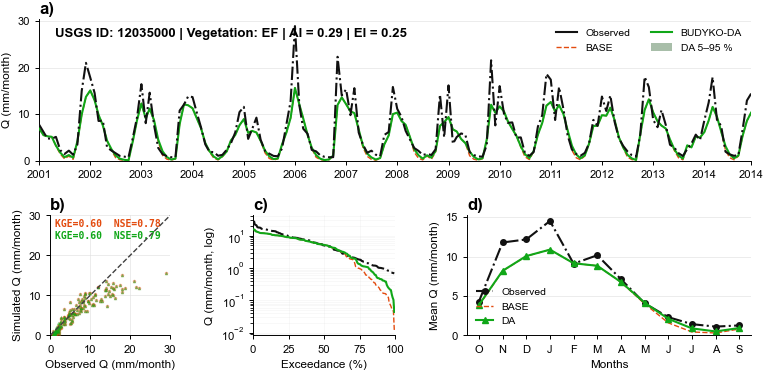

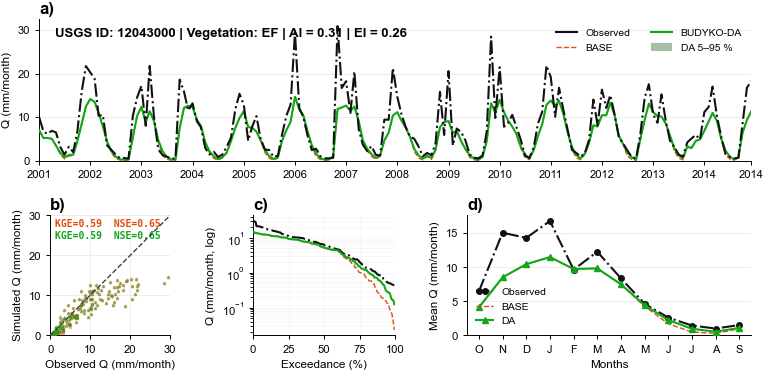

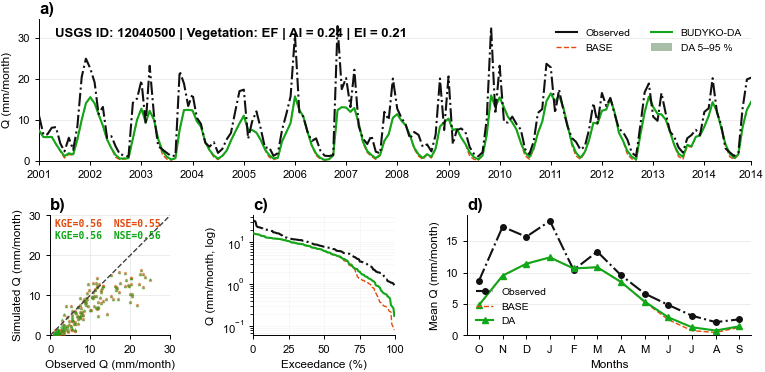

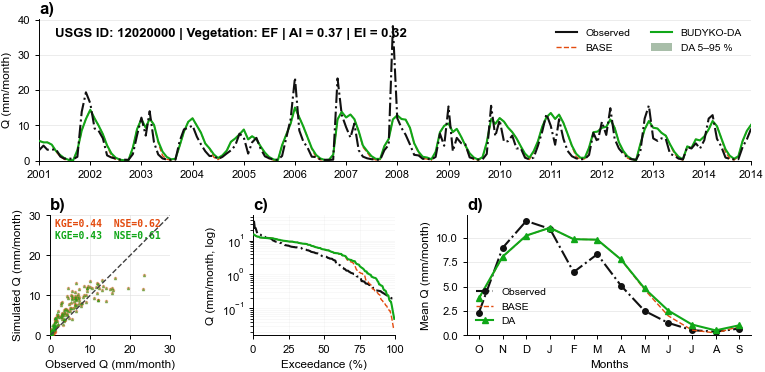

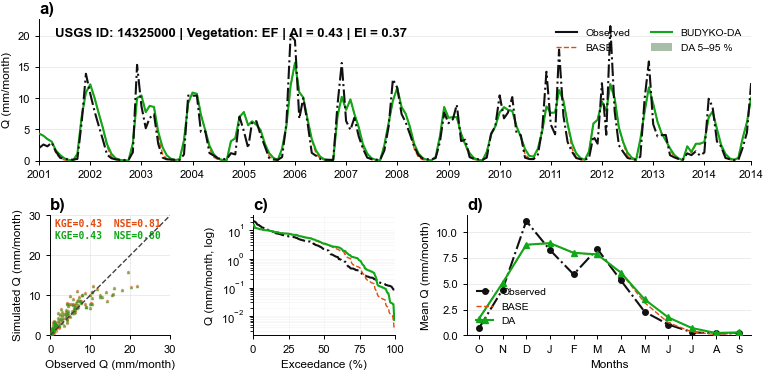

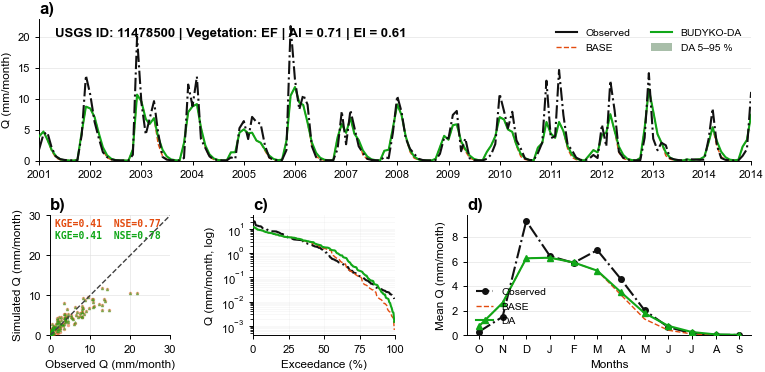

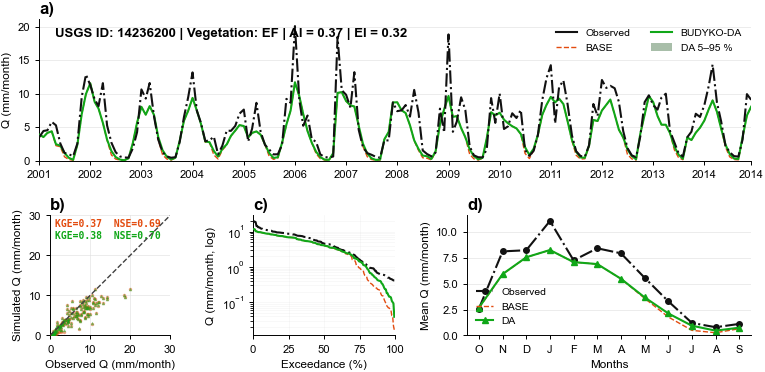

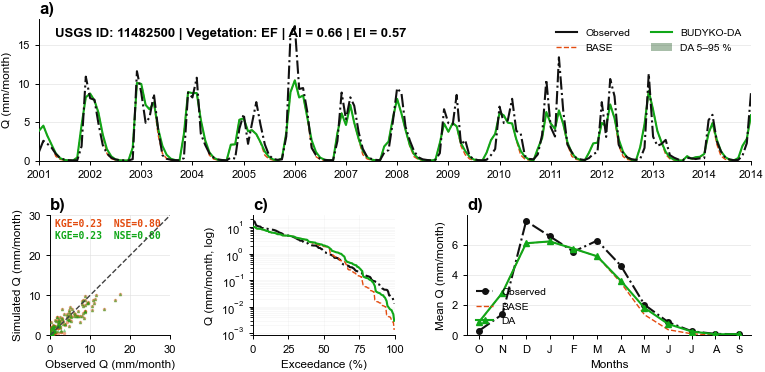

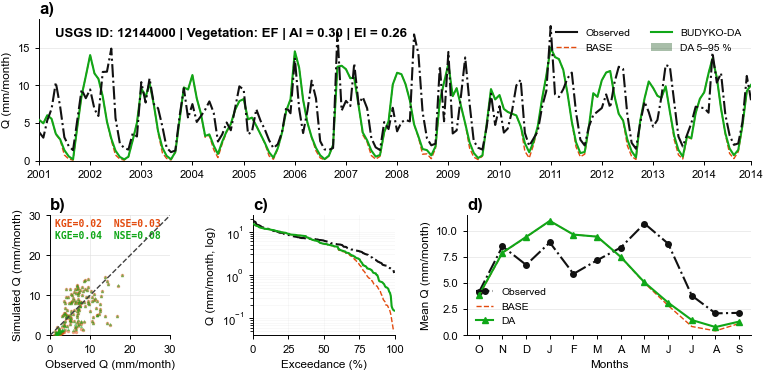

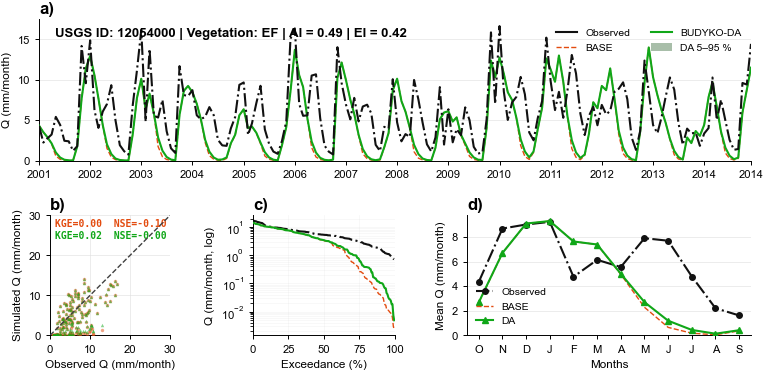

In [201]:
from __future__ import annotations
import os, warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

warnings.filterwarnings("ignore")

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Arial", "DejaVu Sans"],
    "font.size": 8.5, "axes.titlesize": 9, "axes.labelsize": 8.5,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "legend.fontsize": 8, "legend.framealpha": 0.93, "legend.edgecolor": "0.65",
    "axes.linewidth": 0.7, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.major.width": 0.7, "xtick.major.size": 3,
    "ytick.major.width": 0.7, "ytick.major.size": 3,
    "grid.linewidth": 0.4, "grid.color": "0.87",
    "savefig.dpi": 300, "savefig.bbox": "tight", "pdf.fonttype": 42,
})

C  = dict(obs="#111111", base="#E34B0F", da="#10A718", ribbon="#08450B")
LW = dict(obs=1.5, base=1.0, da=1.5)
LS = dict(obs="-.", base="--", da="-")
MON = ["O","N","D","J","F","M","A","M","J","J","A","S"]


# ── Helpers ───────────────────────────────────────────────────────

def _load(path):
    df = pd.read_feather(path)
    for col in ("time", "Date", "date"):
        if col in df.columns:
            df[col] = pd.to_datetime(df[col])
            return df.set_index(col)
    return df

def _get(df, *cols):
    for c in cols:
        if c in df.columns:
            return df[c].values.astype(float)
    return np.full(len(df), np.nan)

def _align(v, si, ti):
    return pd.Series(v, index=si).reindex(ti).values.astype(float)

def _kge(o, s):
    m = np.isfinite(o) & np.isfinite(s); o, s = o[m], s[m]
    if len(o) < 3 or o.std() == 0: return np.nan
    r = np.corrcoef(o, s)[0, 1]
    return float(1 - np.sqrt((r-1)**2 + (s.std()/o.std()-1)**2 + (s.mean()/o.mean()-1)**2))

def _nse(o, s):
    m = np.isfinite(o) & np.isfinite(s); o, s = o[m], s[m]
    d = ((o - o.mean())**2).sum()
    return float(1 - ((o-s)**2).sum()/d) if d > 0 and len(o) > 2 else np.nan


# ── Panels ────────────────────────────────────────────────────────

def _ts(ax, t, obs, base, da, lo, hi):
    ax.fill_between(t, lo, hi, color=C["ribbon"], alpha=0.20, zorder=1)
    ax.plot(t, base, color=C["base"], lw=LW["base"], ls=LS["base"], zorder=2)
    ax.plot(t, da,   color=C["da"],   lw=LW["da"],   ls=LS["da"],   zorder=3)
    ax.plot(t, obs,  color=C["obs"],  lw=LW["obs"],  ls=LS["obs"],  zorder=4)
    ax.set_xlim(t[0], t[-1]); ax.set_ylim(bottom=0)
    ax.set_ylabel("Q (mm/month)")
    ax.set_title("a)", pad=4, loc="left", fontweight="bold", fontsize=12.0)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ticks = list(ax.get_xticks())
    t0n = mdates.date2num(pd.Timestamp(t[0]).to_pydatetime())
    t1n = mdates.date2num(pd.Timestamp(t[-1]).to_pydatetime())
    if ticks and abs(ticks[0]  - t0n) > 15: ticks = [t0n] + ticks
    if ticks and abs(ticks[-1] - t1n) > 15: ticks = ticks + [t1n]
    ax.set_xticks(ticks)
    plt.setp(ax.get_xticklabels(), rotation=0, ha="center")
    ax.grid(axis="y")


def _scatter(ax, obs, base, da, kge_b, kge_da, nse_b, nse_da):
    lim = max(np.nanmax([obs, base, da]) * 1.06, 1.0)
    for sim, color, marker in [(base, C["base"], "o"), (da, C["da"], "^")]:
        m = np.isfinite(obs) & np.isfinite(sim)
        ax.scatter(obs[m], sim[m], s=6, color=color, marker=marker,
                   alpha=0.50, linewidths=0, zorder=3)
    ax.plot([0, 100], [0, 100], color="0.25", lw=1.0, ls="--", zorder=5)
    ax.set_xlim(0, 30); ax.set_ylim(0, 30); ax.set_aspect("equal"); ax.grid(True)
    ax.set_xlabel("Observed Q (mm/month)"); ax.set_ylabel("Simulated Q (mm/month)")
    ax.set_title("b)", pad=4, loc="left", fontweight="bold", fontsize=12.0)
    for txt, col, y0 in [
        (f"KGE={kge_b:.2f}  NSE={nse_b:.2f}",  C["base"], 0.97),
        (f"KGE={kge_da:.2f}  NSE={nse_da:.2f}", C["da"],   0.87),
    ]:
        ax.text(0.04, y0, txt, transform=ax.transAxes, va="top", ha="left",
                fontsize=7, color=col, fontfamily="monospace", fontweight="bold")


def _fdc(ax, obs, base, da):
    def _f(x):
        v = np.sort(x[np.isfinite(x)])[::-1]
        return np.arange(1, len(v)+1)/(len(v)+1)*100, v
    for sim, color, ls, lw in [
        (obs,  C["obs"],  "-.", 1.5),
        (base, C["base"], "--", 1.0),
        (da,   C["da"],   "-",  1.5),
    ]:
        p, v = _f(sim)
        if len(v): ax.semilogy(p, v, color=color, lw=lw, ls=ls, zorder=3)
    ax.set_xlabel("Exceedance (%)"); ax.set_ylabel("Q (mm/month, log)")
    ax.set_xlim(0, 100); ax.grid(True, which="both", alpha=0.35)
    ax.set_title("c)", pad=4, loc="left", fontweight="bold", fontsize=12.0)


def _clim(ax, t, obs, base, da):
    mon  = np.array([d.month for d in t])
    xpos = np.array([(m - 10) % 12 for m in mon])
    for sim, color, ls, lw, marker, label in [
        (obs,  C["obs"],  "-.", 1.5, "o",  "Observed"),
        (base, C["base"], "--", 1.0, None, "BASE"),
        (da,   C["da"],   "-",  1.5, "^",  "DA"),
    ]:
        cl = np.array([np.nanmean(sim[xpos == x]) for x in range(12)])
        ax.plot(range(12), cl, color=color, lw=lw, ls=ls,
                marker=marker, ms=4, label=label, zorder=3)
    ax.set_xticks(range(12)); ax.set_xticklabels(MON)
    ax.set_xlim(-0.5, 11.5); ax.set_ylim(bottom=0)
    ax.set_xlabel("Months"); ax.set_ylabel("Mean Q (mm/month)")
    ax.grid(axis="y")
    ax.legend(loc="lower left", ncol=1, handlelength=1.6, fontsize=7.5, frameon=False)
    ax.set_title("d)", pad=4, loc="left", fontweight="bold", fontsize=12.0)


# ── Main ──────────────────────────────────────────────────────────

def plot_basin_Params(
    gauge_id: str,
    metrics_row: pd.Series,
    result_dir_base: str,
    result_dir_budyko: str,
    result_dir_da: str,
    out_dir: str,
    start_year: int = 2001,
    end_year: int = 2014,
):
    gid = str(gauge_id).zfill(8)

    db  = _load(os.path.join(result_dir_base, f"results_BASE_{gid}.feather"))
    da  = _load(os.path.join(result_dir_da,   f"results_BUDYKO_DA_{gid}.feather"))
    ens = _load(os.path.join(result_dir_da,   f"enkf_ensemble_BUDYKO_DA_{gid}.feather"))

    t_all = ens.loc[f"{start_year}":f"{end_year}-12-31"].index
    obs   = _align(_get(db,  "Q_obs"),         db.index,  t_all)
    base  = _align(_get(db,  "Q_base","Q_ke"), db.index,  t_all)
    da_q  = _align(_get(da,  "Q_ass"),          da.index,  t_all)
    q_lo  = _align(_get(ens, "Q_ens_p05"),     ens.index, t_all)
    q_hi  = _align(_get(ens, "Q_ens_p95"),     ens.index, t_all)

    # KGE/NSE: use pre-computed from metrics_row; fall back to computing from data
    kge_b  = float(metrics_row.get("KGE_Base", _kge(obs, base)))
    kge_da = float(metrics_row.get("KGE_DA",   _kge(obs, da_q)))
    nse_b  = _nse(obs, base)
    nse_da = _nse(obs, da_q)

    fig = plt.figure(figsize=(8.0, 4.0))
    gs_outer = gridspec.GridSpec(2, 1, figure=fig,
                                 left=0.08, right=0.97, top=0.88, bottom=0.09,
                                 hspace=0.42, height_ratios=[1, 0.85])
    ax_ts = fig.add_subplot(gs_outer[0])
    gs_bot = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=gs_outer[1],
                                              wspace=0.38, width_ratios=[1, 1, 2])
    ax_sc  = fig.add_subplot(gs_bot[0])
    ax_fdc = fig.add_subplot(gs_bot[1])
    ax_cl  = fig.add_subplot(gs_bot[2])

    _ts(ax_ts, t_all, obs, base, da_q, q_lo, q_hi)
    _scatter(ax_sc, obs, base, da_q, kge_b, kge_da, nse_b, nse_da)
    _fdc(ax_fdc, obs, base, da_q)
    _clim(ax_cl, t_all, obs, base, da_q)

    ax_ts.legend(
        handles=[
            Line2D([0],[0], color=C["obs"],  lw=1.5, ls="-",  label="Observed"),
            Line2D([0],[0], color=C["base"], lw=1.0, ls="--", label="BASE"),
            Line2D([0],[0], color=C["da"],   lw=1.5, ls="-",  label="BUDYKO-DA"),
            Patch(fc=C["ribbon"], alpha=0.35,                 label="DA 5–95 %"),
        ],
        loc="upper right", ncol=2, fontsize=7.5, handlelength=2.0,
        framealpha=0.95, edgecolor="0.65", frameon=False,
    )

    ai  = metrics_row.get("AI_ass",  metrics_row.get("aridity",  np.nan))
    ei  = metrics_row.get("EI_base", metrics_row.get("EI_ass",   np.nan))
    veg = str(metrics_row.get("dom_land_cover_short", metrics_row.get("dom_land_cover", "—")))
    ai_s = f"{float(ai):.2f}" if pd.notna(ai) else "—"
    ei_s = f"{float(ei):.2f}" if pd.notna(ei) else "—"

    fig.suptitle(
        f"USGS ID: {gid} | Vegetation: {veg} | AI = {ai_s} | EI = {ei_s}",
        fontsize=9.5, fontweight="bold", x=0.1, y=0.86, ha="left",
    )

    os.makedirs(out_dir, exist_ok=True)
    path = os.path.join(out_dir, f"Figures_Global_Params_{gid}.png")
    fig.savefig(path, dpi=300)
    print(f"  ✓  {path}")


def plot_top20_basin_Params(
    top20_df: pd.DataFrame,
    result_dir_base: str,
    result_dir_budyko: str,
    result_dir_da: str,
    out_dir: str,
    start_year: int = 2001,
    end_year: int = 2014,
):
    """One dashboard per row. Required cols: gauge_id, KGE_DA, KGE_Base."""
    for _, row in top20_df.iterrows():
        gid = str(row["gauge_id"]).zfill(8)
        print(f"\n── {gid}  KGE_DA={row['KGE_DA']:.3f}")
        plot_basin_Params(gid, row, result_dir_base, result_dir_budyko,
                          result_dir_da, out_dir, start_year, end_year)


# ── CONFIG ────────────────────────────────────────────────────────
if __name__ == "__main__":

    ROOT = r"F:\Github_repos\Bayesian_DA_Budyko_modeling"
    SIM  = os.path.join(ROOT, "Simulation_results", "Simulation_with_GLOBAL_CAL_PARAMS")

    DIRS = dict(
        result_dir_base   = os.path.join(SIM, "BASE_MODEL","TEST"),
        result_dir_budyko = os.path.join(SIM, "BUDYKO_MODEL",'TEST'),
        result_dir_da     = os.path.join(SIM, "BUDYKO_DA", 'TEST'),
        out_dir           = os.path.join(SIM, "Figures_Global_Params"),
    )

    top20_KGE_DA = (
        attrs_all_simu_mean_505_basins_GLOBAL_CAL
        .dropna(subset=["KGE_DA"])
        .sort_values("KGE_DA", ascending=False)
        .head(10)
        .reset_index(drop=True)
    )
    plot_top20_basin_Params(top20_KGE_DA, **DIRS, start_year=2001, end_year=2014)

# Dynamic Monthly Budyko Validation: Individual Basins

  Loaded 505 basins | Top 6:
    01413500  KGE_B=0.852  veg=DBF  AI=0.54
    03021350  KGE_B=0.815  veg=CL/NVM  AI=0.61
    03187500  KGE_B=0.811  veg=—  AI=nan
    05454000  KGE_B=0.798  veg=—  AI=nan
    06332515  KGE_B=0.786  veg=—  AI=nan
    02112120  KGE_B=0.785  veg=DBF  AI=0.79
  ✓  F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_BASIN_CALIB_PARAMS\figures\fig_ET_validation_6basins.png


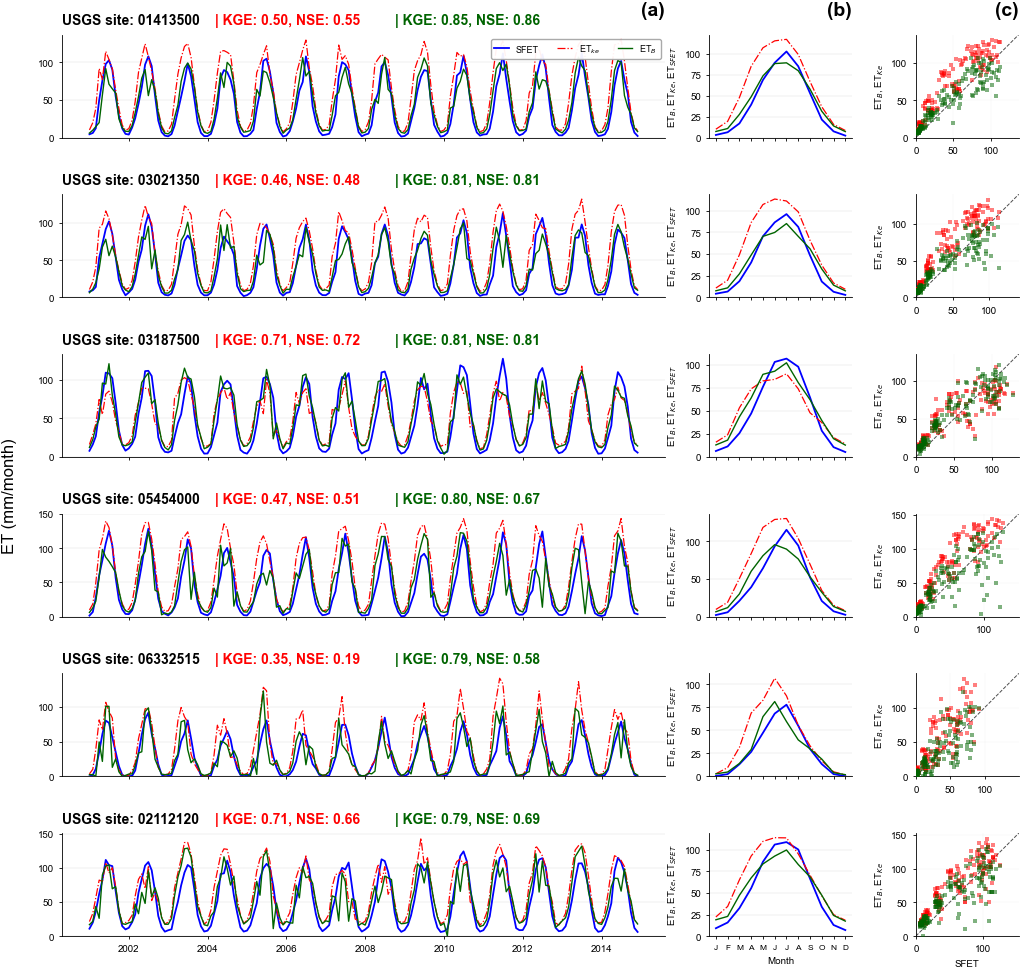

In [344]:
import pandas as pd

SFTET = pd.read_feather(
    r"F:\Github_repos\Bayesian_DA_Budyko_modeling\data\processed\SFET.feather"
)

# Convert time to datetime
SFTET["time"] = pd.to_datetime(SFTET["time"])

# Set time as index
SFTET = SFTET.set_index("time").sort_index()

# Keep only 2000–2014
SFTET_2000_2014 = SFTET.loc["2000-01-01":"2014-12-31"]

# Aggregate daily ET to monthly ET
SFTET_monthly = SFTET_2000_2014.resample("MS").sum()

# Force complete monthly time index: Jan 2000 to Dec 2014
monthly_index = pd.date_range("2000-01-01", "2014-12-01", freq="MS")
SFTET_monthly = SFTET_monthly.reindex(monthly_index)

# Put time back as a column
SFTET_monthly = SFTET_monthly.reset_index().rename(columns={"index": "time"})

SFTET_monthly.columns


"""
plot_et_validation.py
=====================
Six-basin ET validation figure — 6 rows × 3 columns.

Row  = one basin (top 6 by KGE_B vs SFET)
Col  = (a) hydrograph  |  (b) regime curve  |  (c) scatter ET vs SFET

Row title (above col a):
  Basin: XXXXXXXX  |  KGE=X.XX, NSE=X.XX  |  KGE=X.XX, NSE=X.XX  |  VEG  |  AI: X.XX

ET columns stored as mm/day → converted to mm/month here.
SFET pre-processed to mm/month (pass as SFTET_monthly).
attrs_df must have: gauge_id, dom_land_cover_short, aridity (or AI_ass).
"""

from __future__ import annotations
import os, glob, warnings, json
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

warnings.filterwarnings("ignore")

# ── Style ─────────────────────────────────────────────────────────
mpl.rcParams.update({
    "font.family"        : "sans-serif",
    "font.sans-serif"    : ["Helvetica Neue", "Arial", "DejaVu Sans"],
    "font.size"          : 7.5,
    "axes.titlesize"     : 7.5,
    "axes.titleweight"   : "bold",
    "axes.labelsize"     : 7.5,
    "xtick.labelsize"    : 7,
    "ytick.labelsize"    : 7,
    "legend.fontsize"    : 7,
    "legend.framealpha"  : 0,
    "axes.linewidth"     : 0.6,
    "axes.spines.top"    : False,
    "axes.spines.right"  : False,
    "xtick.major.width"  : 0.6,
    "xtick.major.size"   : 2.5,
    "ytick.major.width"  : 0.6,
    "ytick.major.size"   : 2.5,
    "grid.linewidth"     : 0.35,
    "grid.color"         : "0.88",
    "savefig.dpi"        : 300,
    "savefig.bbox"       : "tight",
    "pdf.fonttype"       : 42,
})

C  = dict(sfet="blue", ke="red",  b="darkgreen")
LW = dict(sfet=1.3,       ke=0.9,        b=1.0)
LS = dict(sfet="-",       ke="-.",       b="-")
MON = ["J","F","M","A","M","J","J","A","S","O","N","D"]


# ── Helpers ───────────────────────────────────────────────────────

def _load(path):
    df = pd.read_feather(path)
    for col in ("time","Date","date"):
        if col in df.columns:
            df[col] = pd.to_datetime(df[col])
            return df.set_index(col)
    return df

def _mmmon(arr, days, cap=400.0):
    v = np.asarray(arr, dtype=float) * days
    v[v > cap] = np.nan
    return v

def _kge(o, s):
    m = np.isfinite(o) & np.isfinite(s)
    o, s = o[m], s[m]
    if len(o) < 3 or o.std() == 0: return np.nan
    r = float(np.corrcoef(o, s)[0, 1])
    return float(1 - np.sqrt((r-1)**2+(s.std()/o.std()-1)**2+(s.mean()/o.mean()-1)**2))

def _nse(o, s):
    m = np.isfinite(o) & np.isfinite(s)
    o, s = o[m], s[m]
    if len(o) < 3: return np.nan
    d = ((o - o.mean())**2).sum()
    return float(1 - ((o-s)**2).sum()/d) if d > 0 else np.nan

def _sfet_lookup(sfet_monthly, t0, t1):
    w = sfet_monthly.copy()
    if "time" in w.columns:
        w["time"] = pd.to_datetime(w["time"])
        w = w.set_index("time")
    w.columns = w.columns.str.strip()
    return {(ts.year, ts.month): row.to_dict()
            for ts, row in w.loc[t0:t1].iterrows()}

def _sfet_s(lkp, gid, index):
    return np.array([lkp.get((t.year, t.month), {}).get(gid, np.nan)
                     for t in index], dtype=float)

def _seasonal(et, months):
    # calendar month order Jan=0..Dec=11
    return np.array([np.nanmean(et[months == m]) for m in range(1, 13)])


# ── Data loader ───────────────────────────────────────────────────

def load_data(
    result_dir_base, result_dir_budyko,
    sfet_monthly, attrs_df, calibrated_params_path,
    start_year=2001, end_year=2014, top_n=6,
):
    t0  = pd.Timestamp(f"{start_year}-01-01")
    t1  = pd.Timestamp(f"{end_year}-12-31")
    lkp = _sfet_lookup(sfet_monthly, t0, t1)

    with open(calibrated_params_path) as f:
        cal = json.load(f)

    adf = attrs_df.copy()
    if "gauge_id" in adf.columns:
        adf["gauge_id"] = adf["gauge_id"].astype(str).str.zfill(8)
        adf = adf.set_index("gauge_id")
    else:
        adf.index = adf.index.astype(str).str.zfill(8)

    common = sorted(
        {os.path.basename(f).replace("results_BASE_","").replace(".feather","")
         for f in glob.glob(os.path.join(result_dir_base,"results_BASE_*.feather"))}
        &
        {os.path.basename(f).replace("results_BUDYKO_","").replace(".feather","")
         for f in glob.glob(os.path.join(result_dir_budyko,"results_BUDYKO_*.feather"))}
    )

    basin_data = {}
    kge_b_rank = {}

    for gid in common:
        try:
            db = _load(os.path.join(result_dir_base,
                       f"results_BASE_{gid}.feather")).loc[t0:t1]
            dd = _load(os.path.join(result_dir_budyko,
                       f"results_BUDYKO_{gid}.feather")).loc[t0:t1]

            days   = db.index.days_in_month.values.astype(float)
            sfet   = _sfet_s(lkp, gid, db.index)
            months = np.array([d.month for d in db.index])

            et_ke = _mmmon(db["ET_ke"].values if "ET_ke" in db.columns
                           else np.full(len(db), np.nan), days)
            if gid in cal and "Ke" in cal[gid] and "PET" in db.columns:
                et_ke_scaled = _mmmon(db["PET"].values * float(cal[gid]["Ke"]), days)
            else:
                et_ke_scaled = et_ke.copy()
            et_b  = _mmmon(dd["ET_B"].values if "ET_B" in dd.columns
                           else np.full(len(dd), np.nan), days)

            # Metrics
            kge_ke = _kge(sfet, et_ke)
            nse_ke = _nse(sfet, et_ke)
            kge_b  = _kge(sfet, et_b)
            nse_b  = _nse(sfet, et_b)

            # Attrs
            veg = "—"
            ai  = np.nan
            if gid in adf.index:
                row = adf.loc[gid]
                veg = str(row.get("dom_land_cover_short",
                          row.get("dom_land_cover", "—")))
                for ai_col in ("AI_base","aridity","ai","AI"):
                    if ai_col in row.index and pd.notna(row[ai_col]):
                        ai = float(row[ai_col]); break

            basin_data[gid] = dict(
                time=db.index, sfet=sfet, ke=et_ke, b=et_b,
                months=months,
                kge_ke=kge_ke, nse_ke=nse_ke,
                kge_b=kge_b,   nse_b=nse_b,
                veg=veg, ai=ai,
            )
            kge_b_rank[gid] = kge_b

        except Exception:
            continue

    ranked = sorted(
        [(g, v) for g, v in kge_b_rank.items() if np.isfinite(v)],
        key=lambda x: x[1], reverse=True
    )[:top_n]
    top_ids = [r[0] for r in ranked]

    print(f"  Loaded {len(basin_data)} basins | Top {top_n}:")
    for gid, kge in ranked:
        d = basin_data[gid]
        print(f"    {gid}  KGE_B={kge:.3f}  veg={d['veg']}  AI={d['ai']:.2f}")

    return dict(basin_data=basin_data, top_ids=top_ids)


# ── Main figure ───────────────────────────────────────────────────

def plot_et_validation(data, out_dir, fname="fig_ET_validation_6basins"):
    top_ids = data["top_ids"]
    n_rows  = len(top_ids)           # 6
    n_cols  = 3                      # hydrograph | regime | scatter

    fig = plt.figure(figsize=(10.5, n_rows * 1.55 + 0.5))

    gs = gridspec.GridSpec(
        n_rows, n_cols, figure=fig,
        left=0.06, right=0.99,
        top=0.97,  bottom=0.05,
        hspace=0.55, wspace=0.15,
        width_ratios=[3.6, 0.85, 0.85],
    )

    # Column header (only on first row)
    col_titles = ["(a)", "(b)", "(c)"]

    for row_i, gid in enumerate(top_ids):
        d  = data["basin_data"][gid]
        t  = d["time"]
        sfet   = d["sfet"]
        et_ke  = d["ke"]
        et_b   = d["b"]
        months = d["months"]

        ax_ts  = fig.add_subplot(gs[row_i, 0])
        ax_reg = fig.add_subplot(gs[row_i, 1])
        ax_sc  = fig.add_subplot(gs[row_i, 2])

        # ── Row title above hydrograph ────────────────────────────
        kge_ke_s = f"{d['kge_ke']:.2f}" if np.isfinite(d['kge_ke']) else "—"
        nse_ke_s = f"{d['nse_ke']:.2f}" if np.isfinite(d['nse_ke']) else "—"
        kge_b_s  = f"{d['kge_b']:.2f}"  if np.isfinite(d['kge_b'])  else "—"
        nse_b_s  = f"{d['nse_b']:.2f}"  if np.isfinite(d['nse_b'])  else "—"
        ai_s     = f"{d['ai']:.2f}"      if np.isfinite(d['ai'])     else "—"

        title_parts = [
            (f"USGS site: {gid}", "k",       "bold"),
            (f" | KGE: {kge_ke_s}, NSE: {nse_ke_s}", C["ke"], "bold"),
            (f" | KGE: {kge_b_s}, NSE: {nse_b_s}",  C["b"],  "bold")
            # (f" |  {d['veg']}  |  AI: {ai_s}",        "k",     "normal"),
        ]
        x_pos = 0.0
        for txt, col, wt in title_parts:
            ax_ts.text(x_pos, 1.07, txt,
                       transform=ax_ts.transAxes,
                       fontsize=10, color=col, fontweight=wt,
                       va="bottom", ha="left", clip_on=False)
            # Approximate advance (character width ~0.013 per char in axes coords)
            x_pos += len(txt) * 0.013

        # ── Col headers on first row only ─────────────────────────
        if row_i == 0:
            for ax_h, ctitle in zip([ax_ts, ax_reg, ax_sc], col_titles):
                ax_h.set_title(ctitle, fontsize=14, fontweight="bold",
                               loc="right", pad=14)

        # ── (a) Hydrograph ────────────────────────────────────────
        ax_ts.plot(t, sfet,  color=C["sfet"], lw=LW["sfet"], ls=LS["sfet"],
                   label="SFET")
        ax_ts.plot(t, et_ke, color=C["ke"],   lw=LW["ke"],   ls=LS["ke"],
                   label="ET$_{ke}$")
        ax_ts.plot(t, et_b,  color=C["b"],    lw=LW["b"],    ls=LS["b"],
                   label="ET$_B$")

        ax_ts.xaxis.set_major_locator(mdates.YearLocator(2))
        ax_ts.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        ax_ts.set_ylim(bottom=0)
        ax_ts.grid(axis="y")
        if row_i == 0:
            ax_ts.legend(loc="upper right", ncol=3, fontsize=6.5,
                         handlelength=1.6, frameon=1, edgecolor="0.65", framealpha=0.95)
        if row_i < n_rows - 1:
            ax_ts.set_xticklabels([])
        else:
            ax_ts.set_xlabel(" ", fontsize=7)

        # ── (b) Regime curve ──────────────────────────────────────
        x = np.arange(12)
        for et, k in [(sfet,"sfet"),(et_ke,"ke"),(et_b,"b")]:
            seas = _seasonal(et, months)
            ax_reg.plot(x, seas, color=C[k], lw=LW[k], ls=LS[k])
        ax_reg.set_xticks(x)
        if row_i < n_rows - 1:
            ax_reg.set_xticklabels([])
        else:
            ax_reg.set_xticklabels(MON, fontsize=6)
            ax_reg.set_xlabel("Month", fontsize=7)
        ax_reg.set_ylim(bottom=0)
        ax_reg.set_ylabel("ET$_B$, ET$_{Ke}$, ET$_{SFET}$", fontsize=7)
        ax_reg.grid(axis="y")

        # ── (c) Scatter ET vs SFET ────────────────────────────────
        all_vals = np.concatenate([v for v in [sfet, et_ke, et_b]
                                   if np.any(np.isfinite(v))])
        lim = float(np.nanmax(all_vals)) * 1.06 if len(all_vals) else 1.0
        lim = max(lim, 1.0)

        ax_sc.plot([0, lim], [0, lim], color="0.30", lw=0.7, ls="--", zorder=2)
        for et, k in [(et_ke,"ke"),(et_b,"b")]:
            m = np.isfinite(sfet) & np.isfinite(et)
            ax_sc.scatter(sfet[m], et[m], s=10, color=C[k],
                          alpha=0.50, linewidths=0, zorder=3, marker='s')
        ax_sc.set_xlim(0, lim); ax_sc.set_ylim(0, lim)
        ax_sc.set_aspect("equal")
        ax_sc.grid(True, alpha=0.30)
        ax_sc.set_ylabel("ET$_B$, ET$_{Ke}$", fontsize=7)
        if row_i == n_rows - 1:
            ax_sc.set_xlabel("SFET", fontsize=7)
            

    # Shared y-axis label (centre of figure, left side)
    fig.text(0.01, 0.5, "ET (mm/month)",
             va="center", ha="center", rotation="vertical", fontsize=12)

    # # Column header for regime and scatter (shared x)
    # fig.text(0.665, 0.972, "Regime Curve", ha="center", fontsize=7.5, fontweight="bold")
    # fig.text(0.870, 0.972, "ET vs SFET",  ha="center", fontsize=7.5, fontweight="bold")

    os.makedirs(out_dir, exist_ok=True)
    path = os.path.join(out_dir, f"{fname}.png")
    fig.savefig(path, dpi=300)
    print(f"  ✓  {path}")
    # plt.close(fig)


# ── CONFIG ────────────────────────────────────────────────────────

if __name__ == "__main__":

    ROOT = r"F:\Github_repos\Bayesian_DA_Budyko_modeling"
    SIM  = os.path.join(ROOT, "Simulation_results",
                        "Simulation_with_BASIN_CALIB_PARAMS")

    data = load_data(
        result_dir_base        = os.path.join(SIM, "BASE_MODEL"),
        result_dir_budyko      = os.path.join(SIM, "BUDYKO_MODEL"),
        sfet_monthly           = SFTET_monthly,
        attrs_df               = attrs_all_simu_mean_505_basins_BASIN_CAL,
        calibrated_params_path = os.path.join(ROOT, "SCE_cal_params",
                                              "calibrated_params.json"),
        start_year = 2001,
        end_year   = 2014,
        top_n      = 6,
    )
    plot_et_validation(data, out_dir=os.path.join(SIM, "figures"))

# Dynamic Monthly Budyko Validation: Multiple Basins

  Basins in both BASE and BUDYKO: 505
  SFET diagnostic — basin 01013500: 168/168 months, mean=38.42 mm/month
    03455500: SFET all-NaN
    06354000: SFET all-NaN
    06360500: SFET all-NaN
    06447000: SFET all-NaN
    06452000: SFET all-NaN
  ✓  F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_BASIN_CALIB_PARAMS\figures\fig_ET_validation_mean505.png


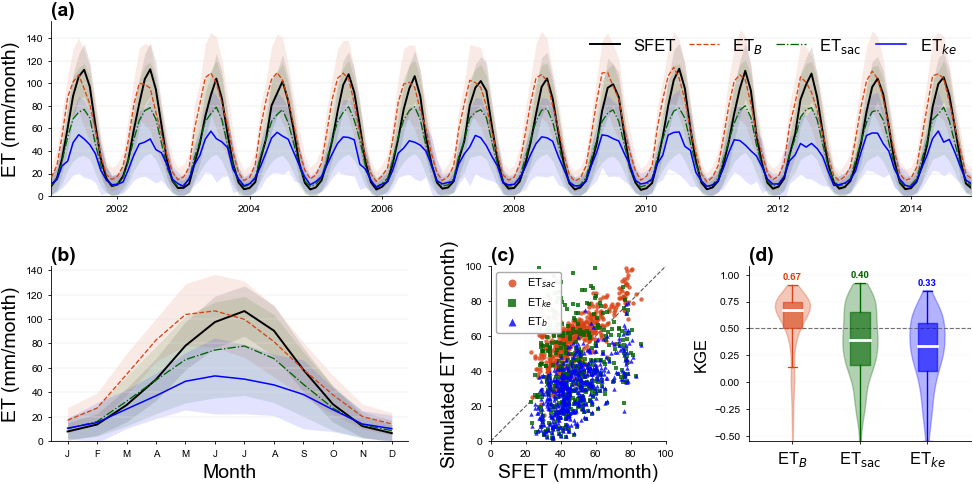

In [417]:
"""
plot_et_validation_mean505.py
==============================
Mean-of-505-basins ET validation figure.

Layout  (1 row × 4 panels)
--------------------------
(a) Mean monthly time series  2001–2014   ± 1σ shading
(b) Mean seasonal regime curve Jan–Dec    ± 1σ shading
(c) Scatter: 12 monthly means vs SFET     one point per calendar month
(d) KGE violin + box: all basins          three ET products vs SFET

ET products
-----------
ET_sac  – SAC-SMA actual ET  → column "ET_ke" in BASE feather   (mm/day × days)
ET_ke   – Ke × PET baseline  → cal["Ke"] × PET column           (mm/day × days)
ET_B    – Budyko ET           → column "ET_B"  in BUDYKO feather (mm/day × days)
SFET    – reference           → SFTET_monthly (DatetimeIndex, mm/month already)

Requirements
------------
SFTET_monthly : pd.DataFrame
    DatetimeIndex (MS), basin IDs as columns, values in mm/month.
    No trailing spaces on columns. Starts March 2000 or earlier.
    Build it as:
        SFTET = pd.read_feather(...SFET.feather...)
        SFTET.columns = SFTET.columns.str.strip()
        SFTET["time"] = pd.to_datetime(SFTET["time"])
        SFTET = SFTET.set_index("time").sort_index()
        SFTET_monthly = SFTET.loc["2000-01-01":"2014-12-31"].resample("MS").sum(min_count=20)
        # Do NOT reset_index — keep DatetimeIndex

Call
----
    data = load_data_mean505(
        result_dir_base        = ...,
        result_dir_budyko      = ...,
        sfet_monthly           = SFTET_monthly,
        calibrated_params_path = ...,
        start_year = 2001,
        end_year   = 2014,
    )
    plot_et_validation_mean505(data, out_dir=...)
"""

from __future__ import annotations
import os
import glob
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

warnings.filterwarnings("ignore")

# ── Style ──────────────────────────────────────────────────────────────────────
mpl.rcParams.update({
    "font.family"       : "sans-serif",
    "font.sans-serif"   : ["Helvetica Neue", "Arial", "DejaVu Sans"],
    "font.size"         : 8,
    "axes.titlesize"    : 9,
    "axes.titleweight"  : "bold",
    "axes.labelsize"    : 8,
    "xtick.labelsize"   : 7.5,
    "ytick.labelsize"   : 7.5,
    "legend.fontsize"   : 7.5,
    "legend.framealpha" : 0.95,
    "axes.linewidth"    : 0.6,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "xtick.major.width" : 0.6,
    "xtick.major.size"  : 2.5,
    "ytick.major.width" : 0.6,
    "ytick.major.size"  : 2.5,
    "grid.linewidth"    : 0.35,
    "grid.color"        : "0.88",
    "savefig.dpi"       : 300,
    "savefig.bbox"      : "tight",
    "pdf.fonttype"      : 42,
})

C  = dict(sfet="black", sac="#D84315", ke="darkgreen", b="blue")
LW = dict(sfet=1.4,       sac=0.95,     ke=0.95,      b=1.1)
LS = dict(sfet="-",       sac="--",     ke="-.",       b="-")
SHAD = 0.11
MON  = ["J","F","M","A","M","J","J","A","S","O","N","D"]


# ══════════════════════════════════════════════════════════════════════════════
# PURE HELPER FUNCTIONS  (no side-effects, no file I/O)
# ══════════════════════════════════════════════════════════════════════════════

def _to_ms_index(df: pd.DataFrame) -> pd.DataFrame:
    """
    Ensure df has a monthly MS DatetimeIndex.
    Handles:
      * 'time' / 'Date' / 'date' column  -> set as index
      * Already a DatetimeIndex           -> floor to day-1 of month
    Uses pd.to_datetime(year/month/day dict) to avoid to_period('MS')
    which is unsupported on some pandas versions.
    """
    for col in ("time", "Date", "date", "TIME"):
        if col in df.columns:
            df = df.copy()
            df[col] = pd.to_datetime(df[col])
            df = df.set_index(col)
            break
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("Cannot find a datetime index or column.")
    # Floor to first day of each month — works on all pandas versions
    df = df.copy()
    df.index = pd.to_datetime(
        {"year": df.index.year, "month": df.index.month, "day": 1}
    )
    return df


def _slice(df: pd.DataFrame,
           common_index: pd.DatetimeIndex) -> pd.DataFrame:
    """
    Align df to common_index using (year, month) matching.
    Returns a DataFrame with exactly len(common_index) rows.
    Missing months are NaN.
    """
    # Build (year,month) → row mapping
    ym_map = {(ts.year, ts.month): i for i, ts in enumerate(df.index)}
    rows = []
    for ts in common_index:
        key = (ts.year, ts.month)
        if key in ym_map:
            rows.append(df.iloc[ym_map[key]])
        else:
            rows.append(pd.Series(np.nan, index=df.columns))
    return pd.DataFrame(rows, index=common_index, columns=df.columns)


def _mmmon(arr: np.ndarray, days: np.ndarray, cap: float = 500.0) -> np.ndarray:
    """mm/day × days_in_month → mm/month. Values > cap → NaN."""
    v = np.asarray(arr, dtype=float) * np.asarray(days, dtype=float)
    v[v > cap] = np.nan
    return v


def _sfet_for_basin(sfet_monthly: pd.DataFrame,
                    gid: str,
                    common_index: pd.DatetimeIndex) -> np.ndarray:
    """
    Extract SFET mm/month series for basin gid aligned to common_index.
    Uses (year, month) lookup — immune to any timestamp offset or duplicates.
    """
    w = sfet_monthly.copy()

    # Ensure DatetimeIndex
    if not isinstance(w.index, pd.DatetimeIndex):
        if "time" in w.columns:
            w["time"] = pd.to_datetime(w["time"])
            w = w.set_index("time")
        else:
            return np.full(len(common_index), np.nan)

    w.columns = w.columns.str.strip()

    if gid not in w.columns:
        return np.full(len(common_index), np.nan)

    # Extract scalar values safely — squeeze to Series, iterate as floats
    col = w[gid]
    if isinstance(col, pd.DataFrame):
        col = col.iloc[:, 0]   # drop duplicate column

    # Build (year, month) -> float lookup; skip NaN rows
    lkp = {}
    for ts, v in zip(col.index, col.values):
        key = (int(ts.year), int(ts.month))
        try:
            fv = float(v)
            if np.isfinite(fv):
                lkp[key] = fv
        except (TypeError, ValueError):
            pass

    return np.array(
        [lkp.get((ts.year, ts.month), np.nan) for ts in common_index],
        dtype=float,
    )


def _kge(obs: np.ndarray, sim: np.ndarray) -> float:
    m = np.isfinite(obs) & np.isfinite(sim)
    o, s = obs[m], sim[m]
    if len(o) < 3 or o.std() == 0:
        return np.nan
    r = float(np.corrcoef(o, s)[0, 1])
    return float(1 - np.sqrt((r - 1)**2
                             + (s.std() / o.std() - 1)**2
                             + (s.mean() / o.mean() - 1)**2))


def _seasonal(arr: np.ndarray, months: np.ndarray) -> np.ndarray:
    """12-element mean seasonal cycle (Jan=1 … Dec=12)."""
    return np.array([np.nanmean(arr[months == m]) for m in range(1, 13)])


def _mean_std(stack: np.ndarray):
    """Column-wise mean and std across basins (axis=0)."""
    return np.nanmean(stack, axis=0), np.nanstd(stack, axis=0)


def _seas_mean_std(stack: np.ndarray, months: np.ndarray):
    """
    Basin-average seasonal cycle mean and std.
    stack: (n_basins, L)
    Returns two (12,) arrays.
    """
    per_basin = np.vstack([_seasonal(stack[i], months)
                           for i in range(stack.shape[0])])
    return np.nanmean(per_basin, axis=0), np.nanstd(per_basin, axis=0)


# ══════════════════════════════════════════════════════════════════════════════
# DATA LOADER
# ══════════════════════════════════════════════════════════════════════════════

def load_data_mean505(
    result_dir_base: str,
    result_dir_budyko: str,
    sfet_monthly: pd.DataFrame,
    calibrated_params_path: str,
    start_year: int = 2001,
    end_year:   int = 2014,
) -> dict:
    """
    Load all matching BASE + BUDYKO feathers and compute cross-basin statistics.

    Returns a dict consumed by plot_et_validation_mean505().
    """
    t0 = pd.Timestamp(f"{start_year}-01-01")
    t1 = pd.Timestamp(f"{end_year}-12-31")
    common_index = pd.date_range(t0, t1, freq="MS")
    L = len(common_index)
    months_arr = np.array([d.month for d in common_index])

    with open(calibrated_params_path) as f:
        cal = json.load(f)

    # ── Find basins present in both scenario folders ───────────────────────
    base_ids = {
        os.path.basename(p).replace("results_BASE_", "").replace(".feather", "")
        for p in glob.glob(os.path.join(result_dir_base, "results_BASE_*.feather"))
    }
    bud_ids = {
        os.path.basename(p).replace("results_BUDYKO_", "").replace(".feather", "")
        for p in glob.glob(os.path.join(result_dir_budyko, "results_BUDYKO_*.feather"))
    }
    common_basins = sorted(base_ids & bud_ids)
    print(f"  Basins in both BASE and BUDYKO: {len(common_basins)}")

    # ── SFET diagnostic (first basin only) ────────────────────────────────
    _test_gid = common_basins[0]
    _test_sfet = _sfet_for_basin(sfet_monthly, _test_gid, common_index)
    print(f"  SFET diagnostic — basin {_test_gid}: "
          f"{int(np.sum(np.isfinite(_test_sfet)))}/{L} months, "
          f"mean={np.nanmean(_test_sfet):.2f} mm/month")

    # ── Per-basin loop ─────────────────────────────────────────────────────
    sac_stack   = []
    ke_stack    = []
    b_stack     = []
    sfet_stack  = []
    kge_sac_all = []
    kge_ke_all  = []
    kge_b_all   = []
    skipped = 0
    errors  = {}   # gid → error message, for first 5 failures

    for gid in common_basins:

        # ── Load and normalise both feathers ──────────────────────────
        try:
            db_raw = pd.read_feather(
                os.path.join(result_dir_base, f"results_BASE_{gid}.feather"))
            dd_raw = pd.read_feather(
                os.path.join(result_dir_budyko, f"results_BUDYKO_{gid}.feather"))
        except Exception as e:
            errors[gid] = f"read_feather: {e}"
            skipped += 1
            continue

        try:
            db = _to_ms_index(db_raw)
            dd = _to_ms_index(dd_raw)
        except Exception as e:
            errors[gid] = f"_to_ms_index: {e}"
            skipped += 1
            continue

        # ── Align to common_index via (year,month) matching ───────────
        try:
            db = _slice(db, common_index)
            dd = _slice(dd, common_index)
        except Exception as e:
            errors[gid] = f"_slice: {e}"
            skipped += 1
            continue

        # ── Build ET arrays ───────────────────────────────────────────
        days = common_index.days_in_month.values.astype(float)

        try:
            # ET_sac: SAC-SMA actual ET stored as "ET_ke" in BASE feather
            if "ET_ke" in db.columns:
                et_sac = _mmmon(db["ET_ke"].values, days)
            else:
                et_sac = np.full(L, np.nan)

            # ET_ke: Ke × PET  (calibrated Ke from params JSON)
            ke_val = None
            if gid in cal:
                for k in ("Ke", "ke", "KE"):
                    if k in cal[gid]:
                        ke_val = float(cal[gid][k])
                        break
            if ke_val is not None and "PET" in db.columns:
                et_ke = _mmmon(db["PET"].values * ke_val, days)
            else:
                et_ke = et_sac.copy()   # fallback: same as ET_sac

            # ET_B: Budyko ET from BUDYKO feather
            if "ET_B" in dd.columns:
                et_b = _mmmon(dd["ET_B"].values, days)
            else:
                et_b = np.full(L, np.nan)

        except Exception as e:
            errors[gid] = f"ET arrays: {e}"
            skipped += 1
            continue

        # ── SFET for this basin ───────────────────────────────────────
        sfet = _sfet_for_basin(sfet_monthly, gid, common_index)

        if not np.any(np.isfinite(sfet)):
            errors[gid] = "SFET all-NaN"
            skipped += 1
            continue

        # ── Accumulate ────────────────────────────────────────────────
        sac_stack.append(et_sac)
        ke_stack.append(et_ke)
        b_stack.append(et_b)
        sfet_stack.append(sfet)

        kge_sac_all.append(_kge(sfet, et_sac))
        kge_ke_all.append(_kge(sfet, et_ke))
        kge_b_all.append(_kge(sfet, et_b))

    # ── Report ─────────────────────────────────────────────────────────────
    n_valid = len(sfet_stack)
    # print(f"  Valid basins: {n_valid}  |  Skipped: {skipped}")
    if errors:
        # print(f"  First failure reasons (up to 5):")
        for gid, msg in list(errors.items())[:5]:
            print(f"    {gid}: {msg}")

    if n_valid == 0:
        raise RuntimeError(
            "No valid basins loaded. "
            "Check result_dir paths, feather column names, and SFET coverage."
        )

    # ── Stack → (n_valid, L) ───────────────────────────────────────────────
    sac_arr  = np.vstack(sac_stack)
    ke_arr   = np.vstack(ke_stack)
    b_arr    = np.vstack(b_stack)
    sfet_arr = np.vstack(sfet_stack)

    # ── Cross-basin statistics ─────────────────────────────────────────────
    sac_mean,  sac_std  = _mean_std(sac_arr)
    ke_mean,   ke_std   = _mean_std(ke_arr)
    b_mean,    b_std    = _mean_std(b_arr)
    sfet_mean, sfet_std = _mean_std(sfet_arr)

    sac_seas_m,  sac_seas_s  = _seas_mean_std(sac_arr,  months_arr)
    ke_seas_m,   ke_seas_s   = _seas_mean_std(ke_arr,   months_arr)
    b_seas_m,    b_seas_s    = _seas_mean_std(b_arr,    months_arr)
    sfet_seas_m, sfet_seas_s = _seas_mean_std(sfet_arr, months_arr)

    def _clean_kge(lst):
        return np.array([v for v in lst if np.isfinite(v)])

    return dict(
        common_index = common_index,
        n_valid      = n_valid,
        # Time series basin-mean (L,)
        sac_mean=sac_mean,   sac_std=sac_std,
        ke_mean=ke_mean,     ke_std=ke_std,
        b_mean=b_mean,       b_std=b_std,
        sfet_mean=sfet_mean, sfet_std=sfet_std,
        # Seasonal (12,)
        sac_seas_m=sac_seas_m,   sac_seas_s=sac_seas_s,
        ke_seas_m=ke_seas_m,     ke_seas_s=ke_seas_s,
        b_seas_m=b_seas_m,       b_seas_s=b_seas_s,
        sfet_seas_m=sfet_seas_m, sfet_seas_s=sfet_seas_s,
        # Per-basin mean (n_basins,) — one value per basin for scatter
        sac_basin =np.nanmean(sac_arr,  axis=1),
        ke_basin  =np.nanmean(ke_arr,   axis=1),
        b_basin   =np.nanmean(b_arr,    axis=1),
        sfet_basin=np.nanmean(sfet_arr, axis=1),
        # KGE per basin (1-D)
        kge_sac=_clean_kge(kge_sac_all),
        kge_ke =_clean_kge(kge_ke_all),
        kge_b  =_clean_kge(kge_b_all),
    )


# ══════════════════════════════════════════════════════════════════════════════
# VIOLIN + BOX HELPER
# ══════════════════════════════════════════════════════════════════════════════

def _violin_box(ax, vals: np.ndarray, x: float,
                color: str, width: float = 0.52):
    """Draw filled violin + IQR box + whiskers + median label at position x."""
    vals = vals[np.isfinite(vals)]
    if len(vals) < 5:
        return

    # Violin
    parts = ax.violinplot(vals, positions=[x], widths=width,
                          showmeans=False, showmedians=False,
                          showextrema=False)
    for pc in parts["bodies"]:
        pc.set_facecolor(color)
        pc.set_edgecolor(color)
        pc.set_alpha(0.30)

    # Quartiles and whiskers
    q1, med, q3 = np.percentile(vals, [25, 50, 75])
    iqr  = q3 - q1
    wlo  = max(vals[vals >= q1 - 1.5 * iqr].min(), vals.min())
    whi  = min(vals[vals <= q3 + 1.5 * iqr].max(), vals.max())
    hw   = width * 0.28   # half box width

    # IQR box
    ax.fill_betweenx([q1, q3], x - hw, x + hw,
                     color=color, alpha=0.60, zorder=3)
    # Median line
    ax.plot([x - hw, x + hw], [med, med],
            color="white", lw=2.0, zorder=4)
    # Whisker lines
    ax.plot([x, x], [wlo, q1], color=color, lw=1.0, zorder=3)
    ax.plot([x, x], [q3, whi], color=color, lw=1.0, zorder=3)
    # Whisker caps
    cap = hw * 0.5
    ax.plot([x - cap, x + cap], [wlo, wlo], color=color, lw=0.9, zorder=3)
    ax.plot([x - cap, x + cap], [whi, whi], color=color, lw=0.9, zorder=3)

    # Median value label above violin
    ax.text(x, whi + 0.03, f"{med:.2f}",
            ha="center", va="bottom", fontsize=7,
            color=color, fontweight="bold", zorder=5)
    # # Sample size below
    # ax.text(x, wlo - 0.05, f"n={len(vals)}",
    #         ha="center", va="top", fontsize=6,
    #         color="0.50", zorder=5)


# ══════════════════════════════════════════════════════════════════════════════
# MAIN FIGURE
# ══════════════════════════════════════════════════════════════════════════════

def plot_et_validation_mean505(
    data: dict,
    out_dir: str,
    fname: str = "fig_ET_validation_mean505",
):
    idx = data["common_index"]
    n   = data["n_valid"]

    fig = plt.figure(figsize=(10, 5))
    # Row 0: panel (a) time series spans full width
    # Row 1: panels (b) regime wider, (c) scatter, (d) KGE
    gs = gridspec.GridSpec(
        2, 3, figure=fig,
        left=0.065, right=0.985,
        top=0.93,   bottom=0.09,
        hspace=0.40, wspace=0.22,
        height_ratios=[1.0, 1.0],
        width_ratios=[1.6, 1.0, 1.0],
    )
    ax_ts  = fig.add_subplot(gs[0, :])      # row 0, all 3 columns
    ax_reg = fig.add_subplot(gs[1, 0])      # row 1, col 0
    ax_sc  = fig.add_subplot(gs[1, 1])      # row 1, col 1
    ax_kge = fig.add_subplot(gs[1, 2])      # row 1, col 2

    # Shared legend handles
    handles = [
        Line2D([0],[0], color=C["sfet"], lw=LW["sfet"], ls=LS["sfet"],
               label="SFET"),
        Line2D([0],[0], color=C["sac"],  lw=LW["sac"],  ls=LS["sac"],
               label=r"ET$_B$"),
        Line2D([0],[0], color=C["ke"],   lw=LW["ke"],   ls=LS["ke"],
               label=r"ET$_{\rm sac}$ "),
        Line2D([0],[0], color=C["b"],    lw=LW["b"],    ls=LS["b"],
               label=r"ET$_{ke}$"),
    ]

    def _shade(ax, t, m, s, col):
        ax.fill_between(t, m - s, m + s, color=col, alpha=SHAD, lw=0)

    # ══════════════════════════════════════════════════════════
    # (a)  Mean time series
    # ══════════════════════════════════════════════════════════
    for key in ("sfet", "sac", "ke", "b"):
        m = data[f"{key}_mean"]
        s = data[f"{key}_std"]
        ax_ts.plot(idx, m, color=C[key], lw=LW[key], ls=LS[key], zorder=4)
        _shade(ax_ts, idx, m, s, C[key])

    ax_ts.xaxis.set_major_locator(mdates.YearLocator(2))
    ax_ts.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax_ts.set_xlim(idx[0], idx[-1])
    ax_ts.set_ylim(bottom=0)
    ax_ts.set_ylabel("ET (mm/month)", fontsize=14)
    ax_ts.set_xlabel(" ", fontsize=14)
    ax_ts.grid(axis="y")
    ax_ts.legend(handles=handles, loc="upper right",
                 ncol=4, fontsize=12, handlelength=1.8,
                 columnspacing=0.8, frameon=0, edgecolor="0.65")
    ax_ts.set_title(f"(a) ",
                    loc="left", fontsize=14, fontweight="bold", pad=4)

    # ══════════════════════════════════════════════════════════
    # (b)  Mean seasonal regime curve
    # ══════════════════════════════════════════════════════════
    x12 = np.arange(12)
    for key in ("sfet", "sac", "ke", "b"):
        m = data[f"{key}_seas_m"]
        s = data[f"{key}_seas_s"]
        ax_reg.plot(x12, m, color=C[key], lw=LW[key], ls=LS[key])
        ax_reg.fill_between(x12, m - s, m + s,
                            color=C[key], alpha=SHAD, lw=0)

    ax_reg.set_xticks(x12)
    ax_reg.set_xticklabels(MON, fontsize=7)
    ax_reg.set_xlabel("Month", fontsize=14)
    ax_reg.set_ylabel("ET (mm/month)", fontsize=14)
    ax_reg.set_ylim(bottom=0)
    ax_reg.grid(axis="y")
    ax_reg.set_title("(b)", loc="left", fontsize=14,
                     fontweight="bold", pad=4)

    # ══════════════════════════════════════════════════════════
    # (c)  Scatter: one point per basin, three ET products
    # ══════════════════════════════════════════════════════════
    sfet_b = data["sfet_basin"]
    all_v  = np.concatenate([sfet_b,
                             data["sac_basin"],
                             data["ke_basin"],
                             data["b_basin"]])
    lim = float(np.nanmax(all_v[np.isfinite(all_v)])) * 1.08

    ax_sc.plot([0, lim], [0, lim], color="0.35", lw=0.8,
               ls="--", zorder=1)
    markers = dict(sac="o", ke="s", b="^")
    n = data["n_valid"]
    for key in ("sac", "ke", "b"):
        x = sfet_b
        y = data[f"{key}_basin"]
        m = np.isfinite(x) & np.isfinite(y)
        ax_sc.scatter(x[m], y[m],
                      s=10, color=C[key], alpha=0.8,
                      linewidths=0.0, edgecolors="white",
                      zorder=3, marker=markers[key],
                      label=f"ET$_{{{key}}}$")

    ax_sc.set_xlim(0, 100)
    ax_sc.set_ylim(0, 100)
    ax_sc.set_aspect("equal", adjustable="box")
    ax_sc.set_xlabel("SFET (mm/month)", fontsize=14)
    ax_sc.set_ylabel("Simulated ET (mm/month)", fontsize=14)
    ax_sc.grid(True, alpha=0.25)
    ax_sc.legend(fontsize=8, loc="upper left",ncol=1,
                 handletextpad=0.4, frameon=1, edgecolor="0.65",
                 markerscale=1.8)
    ax_sc.set_title("(c)", loc="left", fontsize=14,
                    fontweight="bold", pad=4)

    # ══════════════════════════════════════════════════════════
    # (d)  KGE violin + box
    # ══════════════════════════════════════════════════════
    positions = {"sac": 1.0, "ke": 2.0, "b": 3.0}
    for key, xi in positions.items():
        _violin_box(ax_kge, data[f"kge_{key}"], xi, C[key], width=0.52)

    ax_kge.axhline(0.5, color="0.40", lw=0.8, ls="--",
                   zorder=1)
    ax_kge.set_xticks([1, 2, 3])
    ax_kge.set_xticklabels(
        [r"ET$_B$", r"ET$_{\rm sac}$", r"ET$_{ke}$"], fontsize=12
    )
    ax_kge.set_ylabel("KGE", fontsize=12)
    ax_kge.set_ylim(-0.55, 1.08)
    ax_kge.set_xlim(0.35, 3.65)
    ax_kge.grid(axis="y", alpha=0.30)
    # ax_kge.legend(fontsize=7, loc="lower right",
    #               frameon=True, edgecolor="0.65")
    ax_kge.set_title("(d)", loc="left", fontsize=14,
                     fontweight="bold", pad=4)

    # ── Save ──────────────────────────────────────────────────────────────
    os.makedirs(out_dir, exist_ok=True)
    path = os.path.join(out_dir, f"{fname}.png")
    fig.savefig(path, dpi=300)
    print(f"  ✓  {path}")
    plt.show()
    return fig


# ══════════════════════════════════════════════════════════════════════════════
# ENTRY POINT
# ══════════════════════════════════════════════════════════════════════════════

if __name__ == "__main__":

    ROOT    = r"F:\Github_repos\Bayesian_DA_Budyko_modeling"
    SIM     = os.path.join(ROOT, "Simulation_results",
                           "Simulation_with_BASIN_CALIB_PARAMS")
    OUT_DIR = os.path.join(SIM, "figures")
    CAL_P   = os.path.join(ROOT, "SCE_cal_params", "calibrated_params.json")

    # SFTET_monthly must already be in memory — built as:
    #   SFTET = pd.read_feather(r"...\SFET.feather")
    #   SFTET.columns = SFTET.columns.str.strip()
    #   SFTET["time"] = pd.to_datetime(SFTET["time"])
    #   SFTET = SFTET.set_index("time").sort_index()
    #   SFTET_monthly = SFTET.loc["2000-01-01":"2014-12-31"].resample("MS").sum(min_count=20)
    #   # Do NOT reset_index

    data = load_data_mean505(
        result_dir_base        = os.path.join(SIM, "BASE_MODEL"),
        result_dir_budyko      = os.path.join(SIM, "BUDYKO_MODEL"),
        sfet_monthly           = SFTET_monthly,
        calibrated_params_path = CAL_P,
        start_year = 2001,
        end_year   = 2014,
    )

    plot_et_validation_mean505(data, out_dir=OUT_DIR)

# Fluxes Distributions:

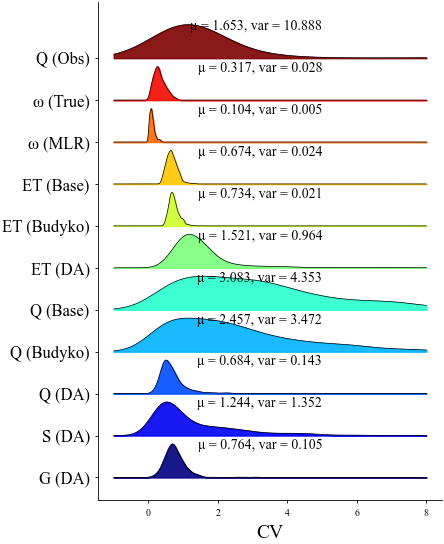

In [340]:



import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.font_manager import FontProperties
from scipy.stats import gaussian_kde
import matplotlib.cm as cm


# ============================================================
# Font / style
# ============================================================
font_path_regular = r"C:/Windows/Fonts/times.ttf"
font_prop = FontProperties(fname=font_path_regular)

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 20


# ============================================================
# Paths
# ============================================================
RESULT_DIR_BASE   = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_BASIN_CALIB_PARAMS\BASE_MODEL"
RESULT_DIR_BUDYKO = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_BASIN_CALIB_PARAMS\BUDYKO_MODEL"
RESULT_DIR_DA     = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_BASIN_CALIB_PARAMS\BUDYKO_DA"


# ============================================================
# Variables (keys stay unchanged)
# ============================================================
target_cols = [
    "Q_obs", "ET_ke", "Q_base",
    "ET_B", "omega_true", "omega_MLR", "Q_budyko",
    "S_ens", "G_ens", "ET_ens", "Q_ens"
]

variable_order = [
    "Q_obs", "omega_true", "omega_MLR",
    "ET_ke", "ET_B", "ET_ens",
    "Q_base", "Q_budyko", "Q_ens",
    "S_ens", "G_ens"
]


# ============================================================
# Scenario mapping (Base / Budyko / DA)
# ============================================================
def scenario_of(var):
    if var in ("Q_obs", "ET_ke", "Q_base"):
        return "Base"
    if var in ("omega_true", "omega_MLR", "ET_B", "Q_budyko"):
        return "Budyko"
    if var in ("S_ens", "G_ens", "ET_ens", "Q_ens"):
        return "DA"
    return np.nan



# ============================================================
# Display labels (ONLY for plotting)
# ============================================================
var_label = {
    "Q_obs":       "Q (Obs)",

    "ET_ke":       "ET (Base)",
    "Q_base":      "Q (Base)",

    "ET_B":        "ET (Budyko)",
    "Q_budyko":    "Q (Budyko)",

    "ET_ens":      "ET (DA)",
    "Q_ens":       "Q (DA)",

    "S_ens":       "S (DA)",
    "G_ens":       "G (DA)",

    "omega_true":  "ω (True)",
    "omega_MLR":   "ω (MLR)",
}


# ============================================================
# Scenario colors
# ============================================================
# cmap = cm.get_cmap("coolwarm")
cmap = cm.get_cmap("coolwarm")
scenario_colors = {
    "Base":   cmap(0.15),
    "Budyko": cmap(0.50),
    "DA":     cmap(0.85),
}


# ============================================================
# File listing
# ============================================================
def list_files(ddir, pattern):
    return sorted(glob.glob(os.path.join(ddir, pattern)))


base_files   = list_files(RESULT_DIR_BASE,   "results_BASE_*.feather")
budyko_files = list_files(RESULT_DIR_BUDYKO, "results_BUDYKO_*.feather")
da_files     = list_files(RESULT_DIR_DA,     "enkf_ensemble_BUDYKO_DA_*.feather")

if not (base_files or budyko_files or da_files):
    raise FileNotFoundError("No BASE / BUDYKO / DA feather files found.")


# ============================================================
# CV helper
# ============================================================
def cv_of_array(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan
    m = np.nanmean(x)
    s = np.nanstd(x, ddof=1)
    if not np.isfinite(m) or m == 0 or not np.isfinite(s):
        return np.nan
    return s / abs(m)


cv_list = {}


# ------------------------
# BASE
# ------------------------
for f in base_files:
    basin_id = os.path.basename(f).replace(".feather", "")
    try:
        df = pd.read_feather(f)
    except Exception:
        continue

    cvs = cv_list.get(basin_id, {})
    for col in ("Q_obs", "ET_ke", "Q_base"):
        cvs[col] = cv_of_array(pd.to_numeric(df.get(col), errors="coerce"))
    cv_list[basin_id] = cvs


# ------------------------
# BUDYKO
# ------------------------
for f in budyko_files:
    basin_id = os.path.basename(f).replace(".feather", "")
    try:
        df = pd.read_feather(f)
    except Exception:
        continue

    cvs = cv_list.get(basin_id, {})
    for col in ("omega_true", "omega_MLR", "ET_B", "Q_budyko"):
        cvs[col] = cv_of_array(pd.to_numeric(df.get(col), errors="coerce"))
    cv_list[basin_id] = cvs


# ------------------------
# DA
# ------------------------
for f in da_files:
    basin_id = os.path.basename(f).replace(".feather", "")
    try:
        df = pd.read_feather(f)
    except Exception:
        continue

    cvs = cv_list.get(basin_id, {})
    for out, src in [
        ("ET_ens", "ET_ens_mean"),
        ("Q_ens",  "Q_ens_mean"),
        ("S_ens",  "S_ens_mean"),
        ("G_ens",  "G_ens_mean"),
    ]:
        cvs[out] = cv_of_array(pd.to_numeric(df.get(src), errors="coerce"))
    cv_list[basin_id] = cvs


# ============================================================
# Build CV dataframe
# ============================================================
cv_df = pd.DataFrame.from_dict(cv_list, orient="index")
cv_df.index.name = "basin"

for c in target_cols:
    if c not in cv_df.columns:
        cv_df[c] = np.nan

cv_df = cv_df[target_cols]


# ============================================================
# Long format
# ============================================================
cv_long = (
    cv_df.reset_index()
    .melt(id_vars="basin", var_name="variable", value_name="cv")
)

cv_long["cv"] = pd.to_numeric(cv_long["cv"], errors="coerce")
cv_long["scenario"] = cv_long["variable"].map(scenario_of)

levels = list(reversed(variable_order))
cv_long["variable"] = pd.Categorical(cv_long["variable"], categories=levels, ordered=True)
cv_long = cv_long.sort_values("variable")


# ============================================================
# Stats
# ============================================================
cv_stats = (
    cv_long.groupby("variable", observed=True)["cv"]
    .agg(mean_cv="mean", var_cv=lambda x: np.nanvar(x, ddof=1))
    .reset_index()
)

cv_stats["label"] = cv_stats.apply(
    lambda r: "μ = NA, var = NA"
    if pd.isna(r["mean_cv"])
    else f"μ = {r['mean_cv']:.3f}, var = {r['var_cv']:.3f}",
    axis=1
)


# ============================================================
# Ridge plot
# ============================================================
x_min, x_max = -1, 8
x_grid = np.linspace(x_min, x_max, 500)

fig, ax = plt.subplots(figsize=(5, 6))
cmap = cm.get_cmap("jet", len(levels))
var_colors = {var: cmap(i) for i, var in enumerate(levels)}


for i, var in enumerate(levels):
    vals = cv_long.loc[cv_long["variable"] == var, "cv"].values
    vals = vals[np.isfinite(vals)]

    if vals.size < 5:
        dens = np.zeros_like(x_grid)
    else:
        kde = gaussian_kde(vals)
        dens = kde(x_grid)
        dens = dens / dens.max() * 0.8 if dens.max() > 0 else dens

    # ax.fill_between(x_grid, i, i + dens, color=scenario_colors[scenario_of(var)], alpha=0.9)

    ax.fill_between(x_grid, i, i + dens,color=var_colors[var],alpha=0.9)

    ax.plot(x_grid, i + dens, color="black", lw=0.5)

ax.set_yticks(range(len(levels)))
ax.set_yticklabels([var_label[v] for v in levels], fontproperties=font_prop, fontsize=12)


ax.set_xlabel("CV", fontsize=14)
ax.set_ylabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

for i, var in enumerate(levels):
    lab = cv_stats.loc[cv_stats["variable"] == var, "label"].values
    ax.text(5, i + 0.6, lab[0] if lab.size else "μ = NA, var = NA",
            ha="right", va="bottom", fontsize=10, fontproperties=font_prop)

plt.tight_layout()
# plt.savefig(
#     r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\plots\ridgeplot_CV.png",
#     dpi=300, bbox_inches="tight"
# )
plt.show()


# Two-Store Bukcet parameters: Outside the DA:

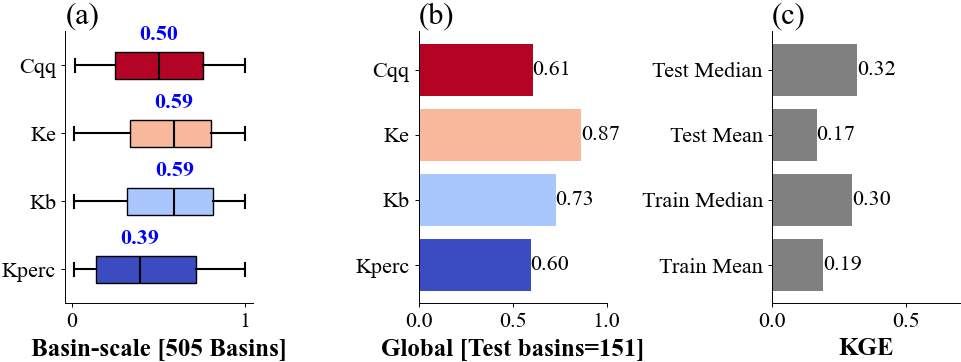

In [213]:
# ============================================================
# Load libraries
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
import json

# ============================================================
# Font settings (Times New Roman)
# ============================================================
LABEL_FONTSIZE = 14

font_path_regular = "C:/Windows/Fonts/times.ttf"
font_path_bold    = "C:/Windows/Fonts/timesbd.ttf"

font_manager.fontManager.addfont(font_path_regular)
font_manager.fontManager.addfont(font_path_bold)

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": LABEL_FONTSIZE,
})

# ============================================================
# Load basin calibration CSV
# ============================================================
param_file_path = (
    "F:/Github_repos/Bayesian_DA_Budyko_modeling/"
    "SCE_cal_params/final_calibrated_params_with_KGE.csv"
)

df = pd.read_csv(param_file_path, index_col="Basin")

# ============================================================
# Prepare boxplot data
# ============================================================
params_to_plot = ["Kperc", "Kb", "Ke", "Cqq"]

df_long = (
    df[params_to_plot]
    .reset_index(drop=True)
    .melt(var_name="Parameter", value_name="Value")
)

df_long["Parameter"] = pd.Categorical(
    df_long["Parameter"],
    categories=params_to_plot,
    ordered=True
)

df_stats = df_long.groupby("Parameter")["Value"].median().reset_index()

# ============================================================
# Load global calibration JSONs
# ============================================================
param_json_path = "F:/Github_repos/Bayesian_DA_Budyko_modeling/SCE_global_params/global_calibrated_params.json"
summary_json_path = "F:/Github_repos/Bayesian_DA_Budyko_modeling/SCE_global_params/global_calibration_summary.json"

with open(param_json_path, "r") as f:
    global_params = json.load(f)

with open(summary_json_path, "r") as f:
    summary = json.load(f)

param_names = ["Kperc", "Kb", "Ke", "Cqq"]
param_values = [global_params[p] for p in param_names]

kge_labels = ["Train Mean", "Train Median", "Test Mean", "Test Median"]
kge_values = [
    summary["mean_train_kge"],
    summary["median_train_kge"],
    summary["mean_test_kge"],
    summary["median_test_kge"],
]

# ============================================================
# Create figure (3 panels)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

# Use JET colormap
cmap = plt.cm.coolwarm

# ============================================================
# (a) Basin distributions
# ============================================================
ax = axes[0]

box_data = [
    df_long[df_long["Parameter"] == p]["Value"].dropna().values
    for p in params_to_plot
]

bp = ax.boxplot(
    box_data,
    vert=False,
    patch_artist=True,
    widths=0.4,
    showfliers=False
)

colors_box = [cmap(i) for i in np.linspace(0, 1, len(params_to_plot))]

for patch, color in zip(bp["boxes"], colors_box):
    patch.set_facecolor(color)
    patch.set_edgecolor("black")

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.5)

# median labels
for i, (param, median) in enumerate(zip(df_stats["Parameter"], df_stats["Value"])):
    ax.text(
        median,
        i + 1.3,
        f"{median:.2f}",
        ha="center",
        va="bottom",
        fontsize=LABEL_FONTSIZE + 2,
        fontweight="bold",
        color="blue"
    )

ax.set_yticks(np.arange(1, len(params_to_plot) + 1))
ax.set_yticklabels(params_to_plot)
ax.set_xlabel("Basin-scale [505 Basins]", fontsize=LABEL_FONTSIZE+4, fontweight="bold")
ax.tick_params(axis="both", labelsize=LABEL_FONTSIZE+2)
ax.set_title("(a)", loc="left", fontsize=LABEL_FONTSIZE+8)

# ============================================================
# (b) Global parameters
# ============================================================
ax = axes[1]

colors_global = [cmap(i) for i in np.linspace(0, 1, len(param_names))]

ax.barh(param_names, param_values, color=colors_global)

for i, v in enumerate(param_values):
    ax.text(v, i, f"{v:.2f}", va="center", fontsize=LABEL_FONTSIZE+2)

ax.set_xlabel("Global [Test basins=151]", fontsize=LABEL_FONTSIZE+4, fontweight="bold")
ax.set_xlim(0, 1)
ax.tick_params(axis="both", labelsize=LABEL_FONTSIZE+2)
ax.set_title("(b)", loc="left", fontsize=LABEL_FONTSIZE+8)

# ============================================================
# (c) KGE performance
# ============================================================
ax = axes[2]

colors_kge = 'grey'

ax.barh(kge_labels, kge_values, color=colors_kge)

for i, v in enumerate(kge_values):
    ax.text(v, i, f"{v:.2f}", va="center", fontsize=LABEL_FONTSIZE+2)

ax.set_xlabel("KGE", fontsize=LABEL_FONTSIZE+4, fontweight="bold")
ax.set_xlim(0, 0.7)
ax.tick_params(axis="both", labelsize=LABEL_FONTSIZE+2)
ax.set_title("(c)", loc="left", fontsize=LABEL_FONTSIZE+8)

# ============================================================
# Remove top & right borders
# ============================================================
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ============================================================
# Final layout
# ============================================================
plt.tight_layout()
plt.show()